Argha Das
ID: 24341220
CSE428 Fall25
BRAC **University** **bold text**

# Dataset Loading

In [ ]:
!pip install kaggle
!pip install opendatasets

In [ ]:
from google.colab import files
files.upload()


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!pip install -q kaggle
!kaggle datasets list

ref                                                 title                                           size  lastUpdated                 downloadCount  voteCount  usabilityRating  
--------------------------------------------------  ----------------------------------------  ----------  --------------------------  -------------  ---------  ---------------  
neurocipher/heartdisease                            Heart Disease                                   3491  2025-12-11 15:29:14.327000           2114        116  1.0              
wardabilal/spotify-global-music-dataset-20092025    Spotify Global Music Dataset (2009–2025)     1289021  2025-11-11 09:43:05.933000          16387        454  1.0              
neurocipher/student-performance                     Student Performance                            49705  2025-12-12 12:06:28.973000           1261         87  1.0              
suvidyasonawane/student-performance-dataset         Student Performance Dataset                    81679  2025

In [ ]:
import opendatasets as od
import pandas

od.download("https://www.kaggle.com/datasets/briscdataset/brisc2025?resource=download")

Dataset URL: https://www.kaggle.com/datasets/briscdataset/brisc2025


100%|██████████| 250M/250M [00:00<00:00, 605MB/s]


In [ ]:
from pathlib import Path

DATA_ROOT = Path("/content/brisc2025/brisc2025")  # adjust if your path is different
print("Exists:", DATA_ROOT.exists())
print(list(DATA_ROOT.iterdir()))


Exists: True
[PosixPath('/content/brisc2025/brisc2025/manifest.csv.sha256'), PosixPath('/content/brisc2025/brisc2025/manifest.csv'), PosixPath('/content/brisc2025/brisc2025/manifest.json.sha256'), PosixPath('/content/brisc2025/brisc2025/classification_task'), PosixPath('/content/brisc2025/brisc2025/manifest.json'), PosixPath('/content/brisc2025/brisc2025/README.md'), PosixPath('/content/brisc2025/brisc2025/segmentation_task')]


In [ ]:
readme_path = DATA_ROOT / "README.md"
print("README exists:", readme_path.exists())

if readme_path.exists():
    print(readme_path.read_text()[:3000])  # show first part


README exists: True
# BRISC 2025 — Brain Tumor MRI Dataset

> **BRISC** (BRain tumor Image Segmentation & Classification) — a curated, expert-annotated T1 MRI dataset for multi-class brain tumor classification and pixel-wise segmentation.

[ArXiv preprint (Fateh et al., 2025)](https://arxiv.org/abs/2506.14318)

---

## 🚀 Overview

BRISC is designed to address common shortcomings in existing public brain MRI collections (e.g., class imbalance, limited tumor types, and annotation inconsistency). It provides high-quality, physician-validated pixel-level masks and a balanced multi-class classification split, suitable for benchmarking segmentation and classification algorithms as well as multi-task learning research.

**Highlights**
- 6,000 T1-weighted MRI slices (5,000 train / 1,000 test)
- Four classes: **Glioma**, **Meningioma**, **Pituitary Tumor**, **No Tumor**
- Pixel-wise segmentation masks reviewed by radiologists
- Slices from three anatomical planes: **Axial**, **Coronal**, **Sagi

In [ ]:
import pandas as pd
import json

csv_path = DATA_ROOT / "manifest.csv"
json_path = DATA_ROOT / "manifest.json"

print("CSV:", csv_path.exists(), "JSON:", json_path.exists())

if csv_path.exists():
    df = pd.read_csv(csv_path)
    display(df.head())
    print("Columns:", df.columns.tolist())
    print("Rows:", len(df))

if json_path.exists():
    manifest = json.loads(json_path.read_text())
    # show top-level keys (structure)
    print("JSON keys:", manifest.keys() if isinstance(manifest, dict) else "list")


CSV: True JSON: True


,relative_path,filename,task,split,index,tumor_code,tumor_label,plane_code,plane_label,sequence,is_mask,linked_image,width,height,file_size_bytes,sha256
0,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00001_gl_ax_t1.jpg,classification,test,1,gl,glioma,ax,axial,T1,False,NaN,512,512,25826,b513a83f68e486f45159b004d356782e78284014532151...
1,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00002_gl_ax_t1.jpg,classification,test,2,gl,glioma,ax,axial,T1,False,NaN,512,512,20982,5b4e4a0f482cb68955c340205d475f25c3a30718bd3b48...
2,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00003_gl_ax_t1.jpg,classification,test,3,gl,glioma,ax,axial,T1,False,NaN,512,512,13285,6fd1918b39e7a7f92fa5652d7802583f3251fed50a23ec...
3,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00004_gl_ax_t1.jpg,classification,test,4,gl,glioma,ax,axial,T1,False,NaN,512,512,26137,216b65a45d7effb4ebce1c9893f97d12449c9da777f818...
4,classification_task\test\glioma\brisc2025_test...,brisc2025_test_00005_gl_ax_t1.jpg,classification,test,5,gl,glioma,ax,axial,T1,False,NaN,512,512,21709,c35734545021ab5a4f55fb87e08732e26fb16abe887927...


Columns: ['relative_path', 'filename', 'task', 'split', 'index', 'tumor_code', 'tumor_label', 'plane_code', 'plane_label', 'sequence', 'is_mask', 'linked_image', 'width', 'height', 'file_size_bytes', 'sha256']
Rows: 15586
JSON keys: list


In [ ]:
for p in [DATA_ROOT/"classification_task", DATA_ROOT/"segmentation_task"]:
    print("\n---", p.name, "---")
    if p.exists():
        for x in p.iterdir():
            print(" ", x.name)



--- classification_task ---
  train
  test

--- segmentation_task ---
  train
  test


In [ ]:
import glob

def count_files(folder: Path, exts=("png","jpg","jpeg","tif","tiff","bmp")):
    files = []
    for e in exts:
        files += list(folder.rglob(f"*.{e}"))
    return len(files), files[:5]

cls_dir = DATA_ROOT / "classification_task"
seg_dir = DATA_ROOT / "segmentation_task"

if cls_dir.exists():
    n, sample = count_files(cls_dir)
    print("Classification images:", n)
    print("Sample files:", sample)

if seg_dir.exists():
    n, sample = count_files(seg_dir)
    print("Segmentation images+masks (all):", n)
    print("Sample files:", sample)


Classification images: 6000
Sample files: [PosixPath('/content/brisc2025/brisc2025/classification_task/train/no_tumor/brisc2025_train_03072_no_co_t1.jpg'), PosixPath('/content/brisc2025/brisc2025/classification_task/train/no_tumor/brisc2025_train_03216_no_sa_t1.jpg'), PosixPath('/content/brisc2025/brisc2025/classification_task/train/no_tumor/brisc2025_train_03255_no_sa_t1.jpg'), PosixPath('/content/brisc2025/brisc2025/classification_task/train/no_tumor/brisc2025_train_02864_no_co_t1.jpg'), PosixPath('/content/brisc2025/brisc2025/classification_task/train/no_tumor/brisc2025_train_03051_no_co_t1.jpg')]
Segmentation images+masks (all): 9586
Sample files: [PosixPath('/content/brisc2025/brisc2025/segmentation_task/train/masks/brisc2025_train_00612_gl_co_t1.png'), PosixPath('/content/brisc2025/brisc2025/segmentation_task/train/masks/brisc2025_train_00563_gl_co_t1.png'), PosixPath('/content/brisc2025/brisc2025/segmentation_task/train/masks/brisc2025_train_02388_me_sa_t1.png'), PosixPath('/con

In [ ]:
import numpy as np
import cv2


# Data Preprocessing

In [ ]:
# ============================================================
# Unified preprocessing + dataset utilities (single source of truth)
# ============================================================
from __future__ import annotations

from dataclasses import dataclass
from pathlib import Path
from typing import Callable, Dict, Optional, Tuple

import numpy as np
import pandas as pd
import cv2
import torch
from torch.utils.data import Dataset


@dataclass(frozen=True)
class PreprocessConfig:
    """Unified preprocessing config used across segmentation/classification/inference."""
    image_size: Tuple[int, int] = (256, 256)  # (H, W)
    grayscale: bool = True
    normalize_01: bool = True
    mask_threshold: float = 0.5
    image_post_fn: Optional[Callable[[np.ndarray], np.ndarray]] = None
    mask_post_fn: Optional[Callable[[np.ndarray], np.ndarray]] = None


def fix_relpath(p: str) -> str:
    """Normalize manifest paths (Windows backslashes -> forward slashes)."""
    return str(p).replace("\\", "/").lstrip("/")


def _as_float01(arr: np.ndarray) -> np.ndarray:
    """
    Convert array to float32 in [0,1] with dtype-aware scaling.
    Supports uint8/uint16 and falls back to min-max scaling.
    """
    if arr.dtype == np.uint8:
        return arr.astype(np.float32) / 255.0
    if arr.dtype == np.uint16:
        return arr.astype(np.float32) / 65535.0

    arr = arr.astype(np.float32)
    mn, mx = float(np.min(arr)), float(np.max(arr))
    if mx - mn < 1e-8:
        return np.zeros_like(arr, dtype=np.float32)
    return (arr - mn) / (mx - mn)


def load_image_tensor(path: Path, cfg: PreprocessConfig) -> torch.Tensor:
    """
    Load an image and return tensor (C,H,W) float32.
    - grayscale=True  -> C=1
    - grayscale=False -> C=3 (RGB)
    """
    path = Path(path)
    img = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {path}")

    if cfg.grayscale:
        if img.ndim == 3:
            img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        if img.ndim == 2:
            img = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = cfg.image_size
    img = cv2.resize(img, (w, h), interpolation=cv2.INTER_AREA)

    img01 = _as_float01(img) if cfg.normalize_01 else img.astype(np.float32)

    if cfg.image_post_fn is not None:
        img01 = cfg.image_post_fn(img01).astype(np.float32)

    if cfg.grayscale:
        x = img01[None, :, :]  # (1,H,W)
    else:
        x = np.transpose(img01, (2, 0, 1))  # (3,H,W)

    return torch.from_numpy(x.astype(np.float32))


def load_mask_tensor(path: Path, cfg: PreprocessConfig) -> torch.Tensor:
    """
    Load a mask and return tensor (1,H,W) float32 with values in {0,1}.
    Uses NEAREST resize to keep labels clean.
    """
    path = Path(path)
    m = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if m is None:
        raise FileNotFoundError(f"Cannot read mask: {path}")

    if m.ndim == 3:
        m = cv2.cvtColor(m, cv2.COLOR_BGR2GRAY)

    h, w = cfg.image_size
    m = cv2.resize(m, (w, h), interpolation=cv2.INTER_NEAREST)

    m01 = _as_float01(m) if cfg.normalize_01 else m.astype(np.float32)

    if cfg.mask_post_fn is not None:
        m01 = cfg.mask_post_fn(m01).astype(np.float32)

    bin_mask = (m01 >= float(cfg.mask_threshold)).astype(np.float32)
    return torch.from_numpy(bin_mask[None, :, :])  # (1,H,W)


# ------------------------------------------------------------------
# Backwards-compatible helpers used in later cells in your notebook
# ------------------------------------------------------------------
def read_gray_01(path: Path, img_size: Optional[Tuple[int, int]] = None) -> np.ndarray:
    """Returns numpy (H,W) float32 in [0,1], resized with INTER_AREA."""
    if img_size is None:
        img_size = globals().get("IMG_SIZE", (256, 256))
    cfg = PreprocessConfig(image_size=(int(img_size[0]), int(img_size[1])), grayscale=True, normalize_01=True)
    x = load_image_tensor(path, cfg)  # (1,H,W)
    return x.squeeze(0).numpy()


def read_mask01(path: Path, img_size: Optional[Tuple[int, int]] = None, threshold: float = 0.5) -> np.ndarray:
    """Returns numpy (H,W) float32 in {0,1}, resized with INTER_NEAREST."""
    if img_size is None:
        img_size = globals().get("IMG_SIZE", (256, 256))
    cfg = PreprocessConfig(
        image_size=(int(img_size[0]), int(img_size[1])),
        grayscale=True,
        normalize_01=True,
        mask_threshold=float(threshold),
    )
    m = load_mask_tensor(path, cfg)  # (1,H,W)
    return m.squeeze(0).numpy()


# ------------------------------------------------------------------
# Dataset adapters (df-based splits)
# ------------------------------------------------------------------
class SegmentationDataset(Dataset):
    """
    Compatible with your existing usage:
        SegmentationDataset(df_seg_masks, DATA_ROOT, img_size=IMG_SIZE)

    Expects df rows with:
        linked_image (image relative path)
        relative_path (mask relative path)
    """

    def __init__(self, df_seg_masks, data_root: Path, img_size=(256, 256)):
        self.df = df_seg_masks.reset_index(drop=True)
        self.data_root = Path(data_root)
        self.cfg = PreprocessConfig(image_size=(int(img_size[0]), int(img_size[1])), grayscale=True)

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img_path = self.data_root / fix_relpath(row["linked_image"])
        mask_path = self.data_root / fix_relpath(row["relative_path"])

        x = load_image_tensor(img_path, self.cfg)  # (1,H,W)
        m = load_mask_tensor(mask_path, self.cfg)  # (1,H,W)
        return x, m


class ClassificationDataset(Dataset):
    """
    Expects df rows with:
        relative_path (image relative path)
        tumor_label (string label)
    """

    def __init__(self, df_cls, data_root: Path, label2id: Dict[str, int], img_size=(256, 256)):
        self.df = df_cls.reset_index(drop=True)
        self.data_root = Path(data_root)
        self.label2id = dict(label2id)
        self.cfg = PreprocessConfig(image_size=(int(img_size[0]), int(img_size[1])), grayscale=True)

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img_path = self.data_root / fix_relpath(row["relative_path"])
        x = load_image_tensor(img_path, self.cfg)  # (1,H,W)
        y = torch.tensor(self.label2id[str(row["tumor_label"])], dtype=torch.long)
        return x, y


class MultiTaskDataset(Dataset):
    """
    Returns: image (1,H,W), mask (1,H,W), class_id (long)

    Uses segmentation-mask rows and pulls tumor_label by matching the linked image in df_full.
    """

    def __init__(self, df_seg_masks, df_full, data_root: Path, label2id: Dict[str, int], img_size=(256, 256)):
        self.df = df_seg_masks.reset_index(drop=True)
        self.df_full = df_full
        self.data_root = Path(data_root)
        self.label2id = dict(label2id)
        self.cfg = PreprocessConfig(image_size=(int(img_size[0]), int(img_size[1])), grayscale=True)

        if "tumor_label" not in self.df_full.columns:
            raise ValueError("df_full must contain tumor_label column for multitask labels")

        img_rows = self.df_full[(self.df_full["task"] == "classification") & (self.df_full["is_mask"] == False)]
        self._label_by_rel = {
            fix_relpath(r): str(l)
            for r, l in zip(img_rows["relative_path"], img_rows["tumor_label"])
            if pd.notna(l)
        }

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img_rel = fix_relpath(row["linked_image"])
        mask_rel = fix_relpath(row["relative_path"])

        img_path = self.data_root / img_rel
        mask_path = self.data_root / mask_rel

        x = load_image_tensor(img_path, self.cfg)
        m = load_mask_tensor(mask_path, self.cfg)

        lab = self._label_by_rel.get(img_rel)
        if lab is None:
            raise KeyError(f"No tumor_label found for linked image: {img_rel}")

        y = torch.tensor(self.label2id[lab], dtype=torch.long)
        return x, m, y

In [ ]:
# Helpers for overlay visualization (paste this ABOVE show_overlays_for_split)

from __future__ import annotations

from pathlib import Path
from typing import Optional, Tuple

import numpy as np
from PIL import Image


def _target_size(size: Optional[Tuple[int, int]] = None) -> Tuple[int, int]:
    """
    Returns (H, W). Tries to reuse common globals if you already defined them.
    """
    if size is not None:
        return int(size[0]), int(size[1])

    if "IMAGE_SIZE" in globals():
        s = globals()["IMAGE_SIZE"]
        if isinstance(s, (tuple, list)) and len(s) == 2:
            return int(s[0]), int(s[1])
        if isinstance(s, int):
            return int(s), int(s)

    if "TARGET_SIZE" in globals():
        s = globals()["TARGET_SIZE"]
        if isinstance(s, (tuple, list)) and len(s) == 2:
            return int(s[0]), int(s[1])
        if isinstance(s, int):
            return int(s), int(s)

    return 256, 256


def fix_relpath(p) -> str:
    return str(p).replace("\\", "/").lstrip("/")


def read_image(path: Path, grayscale: bool = False) -> np.ndarray:
    """
    Returns uint8 image:
      - grayscale=False -> (H,W,3)
      - grayscale=True  -> (H,W)
    """
    img = Image.open(path)
    img = img.convert("L") if grayscale else img.convert("RGB")
    return np.array(img, dtype=np.uint8)


def read_mask(path: Path) -> np.ndarray:
    """
    Returns uint8 mask (H,W) in [0..255].
    """
    m = Image.open(path).convert("L")
    return np.array(m, dtype=np.uint8)


def resize_image(img: np.ndarray, size: Optional[Tuple[int, int]] = None) -> np.ndarray:
    """
    Resizes uint8 image with bilinear.
    """
    h, w = _target_size(size)
    pil = Image.fromarray(img)
    pil = pil.resize((w, h), resample=Image.BILINEAR)
    return np.array(pil, dtype=np.uint8)


def resize_mask(mask: np.ndarray, size: Optional[Tuple[int, int]] = None) -> np.ndarray:
    """
    Resizes mask with nearest neighbor.
    """
    h, w = _target_size(size)
    pil = Image.fromarray(mask)
    pil = pil.resize((w, h), resample=Image.NEAREST)
    return np.array(pil, dtype=np.uint8)


def binarize_mask(mask: np.ndarray, thresh: float = 127.0) -> np.ndarray:
    """
    Returns binary mask (H,W) uint8 in {0,1}.
    Handles masks in uint8 [0..255] or float [0..1].
    """
    if mask.dtype != np.uint8:
        m = np.clip(mask, 0.0, 1.0) * 255.0
        m = m.astype(np.uint8)
    else:
        m = mask
    return (m >= int(thresh)).astype(np.uint8)





=== SEGMENTATION SPLIT: TRAIN | masks=3933 ===


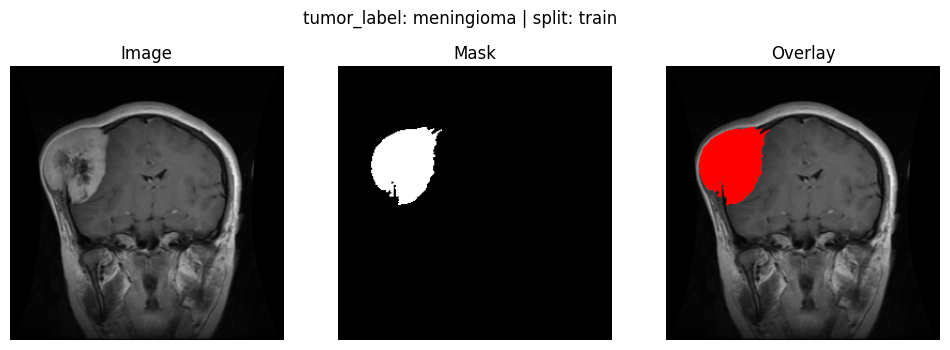

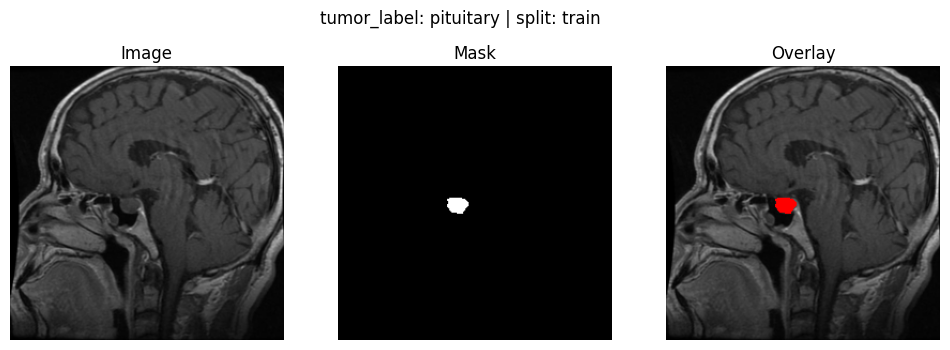

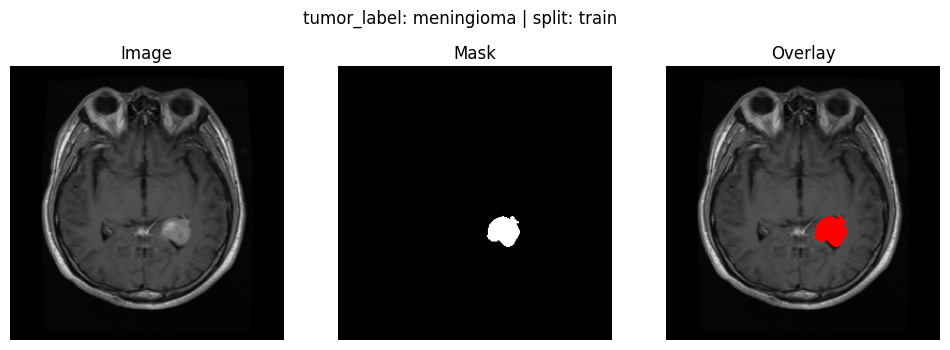


=== SEGMENTATION SPLIT: TEST | masks=860 ===


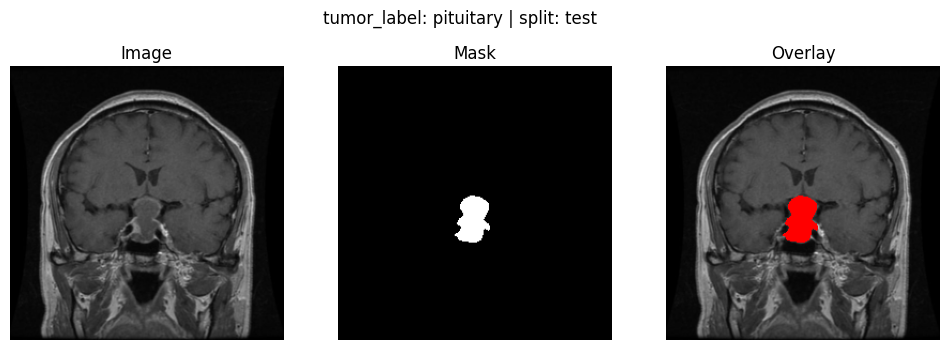

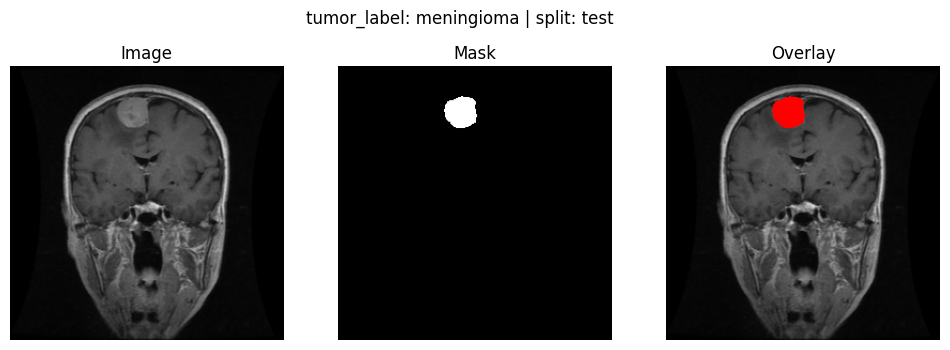

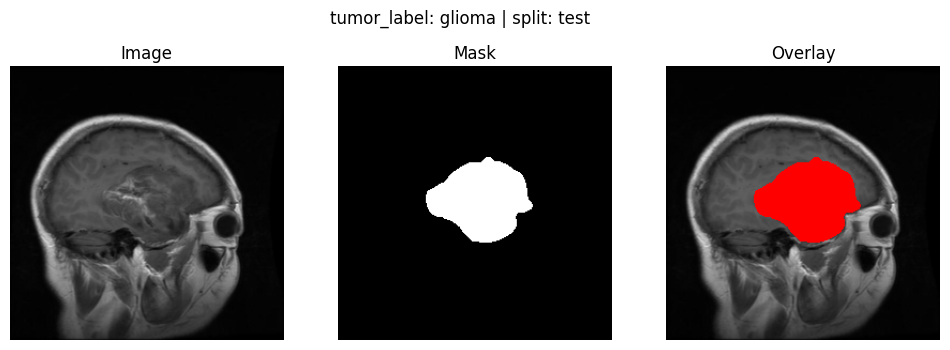

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def fix_relpath(p):
    return str(p).replace("\\", "/")

def show_overlays_for_split(df, split_name="train", n=3):
    seg_masks_split = df[
        (df["task"] == "segmentation") &
        (df["is_mask"] == True) &
        (df["split"] == split_name)
    ].reset_index(drop=True)

    print(f"\n=== SEGMENTATION SPLIT: {split_name.upper()} | masks={len(seg_masks_split)} ===")
    if len(seg_masks_split) == 0:
        print("No masks found for this split.")
        return

    for k in range(n):
        mask_row = seg_masks_split.iloc[np.random.randint(len(seg_masks_split))]

        mask_path = DATA_ROOT / fix_relpath(mask_row["relative_path"])
        img_path  = DATA_ROOT / fix_relpath(mask_row["linked_image"])

        img  = read_image(img_path, grayscale=False)
        mask = read_mask(mask_path)

        img_r  = resize_image(img)
        mask_b = binarize_mask(resize_mask(mask))

        overlay = img_r.copy()
        overlay[mask_b == 1] = (255, 0, 0)

        plt.figure(figsize=(12,4))
        plt.suptitle(f"tumor_label: {mask_row['tumor_label']} | split: {mask_row['split']}", y=0.98)
        plt.subplot(1,3,1); plt.imshow(img_r); plt.title("Image"); plt.axis("off")
        plt.subplot(1,3,2); plt.imshow(mask_b, cmap="gray"); plt.title("Mask"); plt.axis("off")
        plt.subplot(1,3,3); plt.imshow(overlay); plt.title("Overlay"); plt.axis("off")
        plt.show()

# ✅ Run separately (this gives you separate outputs)
show_overlays_for_split(df, "train", n=3)
show_overlays_for_split(df, "test",  n=3)


# Segmentation & Classification

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x):
        return self.conv(self.pool(x))

class Up(nn.Module):
    """
    Correct U-Net up block:
    - Up-sample decoder feature (in_ch -> out_ch)
    - Concatenate skip feature (skip_ch)
    - DoubleConv(out_ch + skip_ch -> out_ch)
    """
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)

        # Pad if needed (odd sizes)
        diffY = skip.size(2) - x.size(2)
        diffX = skip.size(3) - x.size(3)
        x = F.pad(x, [diffX//2, diffX - diffX//2, diffY//2, diffY - diffY//2])

        x = torch.cat([skip, x], dim=1)
        return self.conv(x)
        # Build class_names from manifest
cls_rows = df[(df["task"]=="classification") & (df["is_mask"]==False)].copy()
if len(cls_rows) == 0:
    cls_rows = df[(df["task"]=="segmentation") & (df["is_mask"]==True)].copy()

class_names = sorted(cls_rows["tumor_label"].dropna().unique().tolist())
label2id = {c:i for i,c in enumerate(class_names)}
id2label = {i:c for c,i in label2id.items()}

print("Classes:", class_names)
print("Num classes:", len(class_names))


Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
Num classes: 4


In [ ]:
class UNetWithClassifier(nn.Module):
    """
    Segmentation output: seg_logits (B,1,H,W)
    Classification output: cls_logits (B,num_classes) from encoder bottleneck
    """
    def __init__(self, in_channels=1, num_classes=4, base=32, dropout=0.2):
        super().__init__()

        # Encoder
        self.inc   = DoubleConv(in_channels, base)       # 32
        self.down1 = Down(base, base*2)                  # 64
        self.down2 = Down(base*2, base*4)                # 128
        self.down3 = Down(base*4, base*8)                # 256
        self.bottleneck = DoubleConv(base*8, base*16)    # 512

        # Decoder
        self.up1 = Up(base*16, base*8, base*8)           # 512->256, skip 256
        self.up2 = Up(base*8,  base*4, base*4)           # 256->128, skip 128
        self.up3 = Up(base*4,  base*2, base*2)           # 128->64,  skip 64
        self.up4 = Up(base*2,  base,   base)             # 64->32,   skip 32

        self.seg_out = nn.Conv2d(base, 1, kernel_size=1)

        # Classifier head on bottleneck output
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.cls_head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(base*16, base*8),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(base*8, num_classes)
        )

    def forward(self, x):
        # Encoder
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.bottleneck(x4)

        # Classification from encoder output
        cls_logits = self.cls_head(self.gap(x5))

        # Decoder segmentation
        d1 = self.up1(x5, x4)
        d2 = self.up2(d1, x3)
        d3 = self.up3(d2, x2)
        d4 = self.up4(d3, x1)
        seg_logits = self.seg_out(d4)

        return seg_logits, cls_logits


In [ ]:
bce = nn.BCEWithLogitsLoss()
ce  = nn.CrossEntropyLoss()

def dice_loss(seg_logits, seg_true, eps=1e-7):
    probs = torch.sigmoid(seg_logits)
    num = 2*(probs*seg_true).sum(dim=(2,3))
    den = (probs + seg_true).sum(dim=(2,3)) + eps
    return (1 - (num/den)).mean()

def multitask_loss(seg_logits, cls_logits, seg_true, cls_true, lam_seg=1.0, lam_cls=1.0):
    l_seg = 0.5*bce(seg_logits, seg_true) + 0.5*dice_loss(seg_logits, seg_true)
    l_cls = ce(cls_logits, cls_true)
    total = lam_seg*l_seg + lam_cls*l_cls
    return total, l_seg.detach(), l_cls.detach()


In [ ]:
IMG_SIZE = (256, 256)

def preprocess_single_image(img_path):
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {img_path}")

    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    img01 = img.astype(np.float32) / 255.0
    x = torch.from_numpy(img01)[None, None, :, :]  # (1,1,H,W)
    return x, img01

@torch.no_grad()
def predict_any_image(model, img_path, device, thresh=0.5):
    model.eval()
    x, img01 = preprocess_single_image(img_path)
    x = x.to(device)

    seg_logits, cls_logits = model(x)

    cls_id = int(torch.argmax(cls_logits, dim=1).item())
    cls_name = id2label.get(cls_id, str(cls_id))

    seg_prob = torch.sigmoid(seg_logits)[0,0].cpu().numpy()
    pred_mask = (seg_prob >= thresh).astype(np.uint8)

    return cls_name, cls_id, pred_mask, img01


In [ ]:
def read_mask(mask_path):
    m = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise FileNotFoundError(f"Cannot read mask: {mask_path}")
    return m

def resize_mask(mask):
    return cv2.resize(mask, IMG_SIZE, interpolation=cv2.INTER_NEAREST)

def binarize_mask(mask, thresh=0):
    return (mask > thresh).astype(np.uint8)

def overlay_mask_on_gray(img01, mask01, color="red", alpha=0.35):
    rgb = np.stack([img01]*3, axis=-1)
    overlay = rgb.copy()

    if color == "red":
        overlay[mask01==1] = [1,0,0]
    elif color == "green":
        overlay[mask01==1] = [0,1,0]

    return (1-alpha)*rgb + alpha*overlay


def dice_iou(pred, true, eps=1e-7):
    pred = pred.astype(np.uint8)
    true = true.astype(np.uint8)
    tp = np.sum((pred==1) & (true==1))
    fp = np.sum((pred==1) & (true==0))
    fn = np.sum((pred==0) & (true==1))
    dice = (2*tp + eps) / (2*tp + fp + fn + eps)
    iou  = (tp + eps) / (tp + fp + fn + eps)
    return float(dice), float(iou)

def show_demo_panel(img01, gt_mask, pred_mask, title=""):
    plt.figure(figsize=(12,6))
    plt.suptitle(title, y=0.98)

    # Ground truth row
    plt.subplot(2,3,1); plt.imshow(img01, cmap="gray"); plt.title("Original image"); plt.axis("off")
    plt.subplot(2,3,2); plt.imshow(gt_mask, cmap="gray"); plt.title("Original mask"); plt.axis("off")
    plt.subplot(2,3,3); plt.imshow(overlay_mask_on_gray(img01, gt_mask, "red")); plt.title("Image + GT overlay"); plt.axis("off")

    # Predictions row
    plt.subplot(2,3,4); plt.imshow(img01, cmap="gray"); plt.title("Processed image"); plt.axis("off")
    plt.subplot(2,3,5); plt.imshow(pred_mask, cmap="gray"); plt.title("Predicted mask"); plt.axis("off")
    plt.subplot(2,3,6); plt.imshow(overlay_mask_on_gray(img01, pred_mask, "green")); plt.title("Image + Pred overlay"); plt.axis("off")

    plt.show()


Device: cuda
Image: /content/brisc2025/brisc2025/segmentation_task/train/images/brisc2025_train_01496_me_ax_t1.jpg exists: True
Mask : /content/brisc2025/brisc2025/segmentation_task/train/masks/brisc2025_train_01496_me_ax_t1.png exists: True
GT label: meningioma | split: train
Predicted class: pituitary
Dice=0.000 | IoU=0.000 (untrained => random-ish)


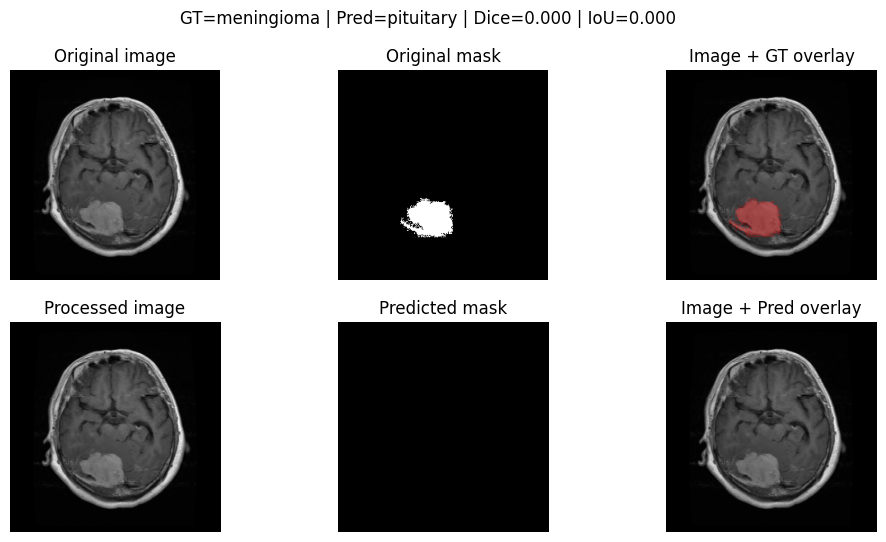

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

model = UNetWithClassifier(in_channels=1, num_classes=len(class_names), base=32).to(device)

# pick a random segmentation mask row (so we have GT mask)
seg_masks = df[(df["task"]=="segmentation") & (df["is_mask"]==True)].reset_index(drop=True)
mask_row = seg_masks.iloc[np.random.randint(len(seg_masks))]

img_path  = DATA_ROOT / fix_relpath(mask_row["linked_image"])
mask_path = DATA_ROOT / fix_relpath(mask_row["relative_path"])

print("Image:", img_path, "exists:", img_path.exists())
print("Mask :", mask_path, "exists:", mask_path.exists())
print("GT label:", mask_row["tumor_label"], "| split:", mask_row["split"])

# ground truth mask
gt_mask = binarize_mask(resize_mask(read_mask(mask_path)))

# predict from ANY image
pred_name, pred_id, pred_mask, img01 = predict_any_image(model, img_path, device=device, thresh=0.9)

# dice/iou for display (random now; meaningful after training)
d, i = dice_iou(pred_mask, gt_mask)

print("Predicted class:", pred_name)
print(f"Dice={d:.3f} | IoU={i:.3f} (untrained => random-ish)")

title = f"GT={mask_row['tumor_label']} | Pred={pred_name} | Dice={d:.3f} | IoU={i:.3f}"
show_demo_panel(img01, gt_mask, pred_mask, title=title)



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from tqdm import tqdm


In [ ]:
class AttentionGate(nn.Module):
    """
    Attention Gate:
    x = skip feature (encoder)
    g = gating feature (decoder)
    output = x * alpha (alpha in [0,1])
    """
    def __init__(self, x_ch, g_ch, inter_ch):
        super().__init__()
        self.W_x = nn.Sequential(
            nn.Conv2d(x_ch, inter_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_ch)
        )
        self.W_g = nn.Sequential(
            nn.Conv2d(g_ch, inter_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(inter_ch)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(inter_ch, 1, kernel_size=1, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x, g):
        theta_x = self.W_x(x)
        phi_g   = self.W_g(g)
        f = self.relu(theta_x + phi_g)
        alpha = self.psi(f)        # (B,1,H,W)
        return x * alpha


In [ ]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x):
        return self.conv(self.pool(x))


In [ ]:
class AttnUp(nn.Module):
    """
    Up block with Attention Gate on skip features:
    - upsample decoder (in_ch -> out_ch)
    - attention(skip, gating=x_up)
    - concat + DoubleConv
    """
    def __init__(self, in_ch, skip_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, out_ch, kernel_size=2, stride=2)
        self.attn = AttentionGate(x_ch=skip_ch, g_ch=out_ch, inter_ch=max(out_ch//2, 1))
        self.conv = DoubleConv(out_ch + skip_ch, out_ch)

    def forward(self, x, skip):
        x = self.up(x)

        diffY = skip.size(2) - x.size(2)
        diffX = skip.size(3) - x.size(3)
        x = F.pad(x, [diffX//2, diffX - diffX//2, diffY//2, diffY - diffY//2])

        skip_attn = self.attn(skip, x)
        x = torch.cat([skip_attn, x], dim=1)
        return self.conv(x)


In [ ]:
class AttentionUNetWithClassifier(nn.Module):
    """
    seg_logits: (B,1,H,W)
    cls_logits: (B,num_classes) from bottleneck
    """
    def __init__(self, in_channels=1, num_classes=4, base=32, dropout=0.2):
        super().__init__()

        # Encoder
        self.inc   = DoubleConv(in_channels, base)       # 32
        self.down1 = Down(base, base*2)                  # 64
        self.down2 = Down(base*2, base*4)                # 128
        self.down3 = Down(base*4, base*8)                # 256
        self.bottleneck = DoubleConv(base*8, base*16)    # 512

        # Decoder (Attention)
        self.up1 = AttnUp(base*16, base*8, base*8)       # 512->256 skip256
        self.up2 = AttnUp(base*8,  base*4, base*4)       # 256->128 skip128
        self.up3 = AttnUp(base*4,  base*2, base*2)       # 128->64  skip64
        self.up4 = AttnUp(base*2,  base,   base)         # 64->32   skip32

        self.seg_out = nn.Conv2d(base, 1, kernel_size=1)

        # Classifier head from bottleneck (optional for this part)
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.cls_head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(base*16, base*8),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(base*8, num_classes)
        )

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.bottleneck(x4)

        cls_logits = self.cls_head(self.gap(x5))

        d1 = self.up1(x5, x4)
        d2 = self.up2(d1, x3)
        d3 = self.up3(d2, x2)
        d4 = self.up4(d3, x1)

        seg_logits = self.seg_out(d4)
        return seg_logits, cls_logits


In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

x = torch.randn(1, 1, 256, 256).to(device)
tmp_model = AttentionUNetWithClassifier(in_channels=1, num_classes=4, base=32).to(device)
seg_logits, cls_logits = tmp_model(x)

print("seg_logits:", seg_logits.shape)  # (1,1,256,256)
print("cls_logits:", cls_logits.shape)  # (1,4)


device: cuda
seg_logits: torch.Size([1, 1, 256, 256])
cls_logits: torch.Size([1, 4])


In [ ]:
bce = nn.BCEWithLogitsLoss()

def dice_loss(seg_logits, seg_true, eps=1e-7):
    probs = torch.sigmoid(seg_logits)
    num = 2*(probs*seg_true).sum(dim=(2,3))
    den = (probs + seg_true).sum(dim=(2,3)) + eps
    return (1 - (num/den)).mean()

def seg_loss_fn(seg_logits, seg_true):
    return 0.5*bce(seg_logits, seg_true) + 0.5*dice_loss(seg_logits, seg_true)


In [ ]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    running = 0.0

    for img, mask in tqdm(loader, leave=False):
        img  = img.to(device)
        mask = mask.to(device)

        optimizer.zero_grad()
        seg_logits, _ = model(img)          # ignore classification output here
        loss = seg_loss_fn(seg_logits, mask)
        loss.backward()
        optimizer.step()

        running += loss.item() * img.size(0)

    return running / len(loader.dataset)

@torch.no_grad()
def eval_one_epoch(model, loader, device):
    model.eval()
    running = 0.0

    for img, mask in tqdm(loader, leave=False):
        img  = img.to(device)
        mask = mask.to(device)

        seg_logits, _ = model(img)
        loss = seg_loss_fn(seg_logits, mask)

        running += loss.item() * img.size(0)

    return running / len(loader.dataset)


### Deprecated
This cell used to redefine `SegmentationDataset` using ad-hoc preprocessing.

✅ Use the unified preprocessing + dataset utilities cell above instead.


In [ ]:
seg_masks = df[(df["task"]=="segmentation") & (df["is_mask"]==True)].copy()

print("Segmentation masks total:", len(seg_masks))
print("Split counts:", seg_masks["split"].value_counts().to_dict())

df_train = seg_masks[seg_masks["split"]=="train"].copy()
df_test  = seg_masks[seg_masks["split"]=="test"].copy()
df_val   = seg_masks[seg_masks["split"].isin(["val","valid","validation"])].copy()

# If no val split exists, create 20% from train
if len(df_val) == 0 and len(df_train) > 0:
    df_train, df_val = train_test_split(
        df_train,
        test_size=0.2,
        random_state=42,
        stratify=df_train["tumor_label"] if "tumor_label" in df_train.columns else None
    )

print("Train masks:", len(df_train))
print("Val masks  :", len(df_val))
print("Test masks :", len(df_test))


Segmentation masks total: 4793
Split counts: {'train': 3933, 'test': 860}
Train masks: 3146
Val masks  : 787
Test masks : 860


In [ ]:
BATCH_SIZE = 8
NUM_WORKERS = 2

train_ds = SegmentationDataset(df_train, DATA_ROOT, img_size=IMG_SIZE)
val_ds   = SegmentationDataset(df_val,   DATA_ROOT, img_size=IMG_SIZE)
test_ds  = SegmentationDataset(df_test,  DATA_ROOT, img_size=IMG_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print("train batches:", len(train_loader))
print("val batches  :", len(val_loader))
print("test batches :", len(test_loader))


train batches: 394
val batches  : 99
test batches : 108


In [ ]:
import torch.optim as optim

epochs = 10
lr = 1e-3

# num_classes not needed for seg training, but model requires it
num_classes = 4  # safe default; classifier output is ignored in seg training

model_attn = AttentionUNetWithClassifier(in_channels=1, num_classes=num_classes, base=32).to(device)
optimizer = optim.Adam(model_attn.parameters(), lr=lr)

history = {"train_loss": [], "val_loss": []}

for ep in range(1, epochs+1):
    tr = train_one_epoch(model_attn, train_loader, optimizer, device)
    vl = eval_one_epoch(model_attn, val_loader, device)

    history["train_loss"].append(tr)
    history["val_loss"].append(vl)

    print(f"Epoch {ep}/{epochs} | train_loss={tr:.4f} | val_loss={vl:.4f}")


Epoch 1/10 | train_loss=0.4216 | val_loss=0.2813


Epoch 2/10 | train_loss=0.2405 | val_loss=0.2433


Epoch 3/10 | train_loss=0.2082 | val_loss=0.2180


Epoch 4/10 | train_loss=0.1860 | val_loss=0.1995


Epoch 5/10 | train_loss=0.1703 | val_loss=0.1962


Epoch 6/10 | train_loss=0.1584 | val_loss=0.1650


Epoch 7/10 | train_loss=0.1425 | val_loss=0.1821


Epoch 8/10 | train_loss=0.1345 | val_loss=0.1546


Epoch 9/10 | train_loss=0.1286 | val_loss=0.1839


Epoch 10/10 | train_loss=0.1259 | val_loss=0.1352


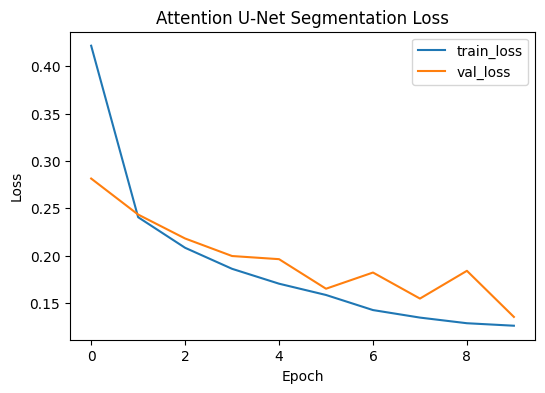

In [ ]:
plt.figure(figsize=(6,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Attention U-Net Segmentation Loss")
plt.legend()
plt.show()



Classification split counts:
split
train    5000
test     1000
Name: count, dtype: int64

Segmentation mask split counts:
split
train    3933
test      860
Name: count, dtype: int64


/tmp/ipython-input-1261918478.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha="right")
/tmp/ipython-input-1261918478.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha="right")


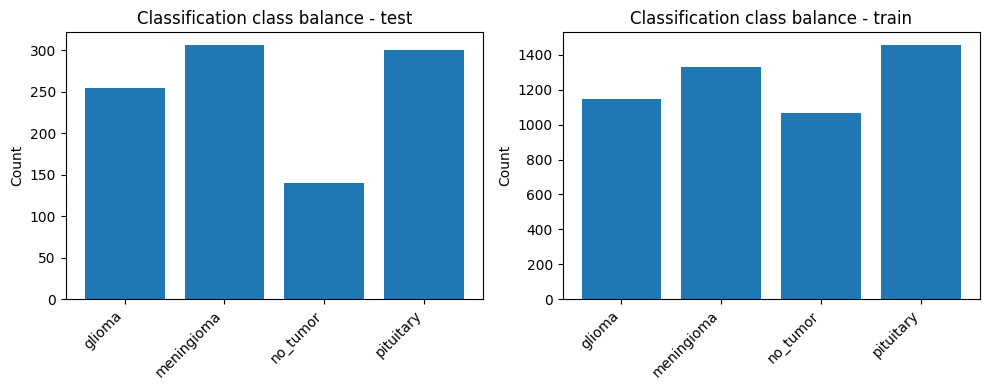

/tmp/ipython-input-1261918478.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha="right")
/tmp/ipython-input-1261918478.py:20: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(counts.index, rotation=45, ha="right")


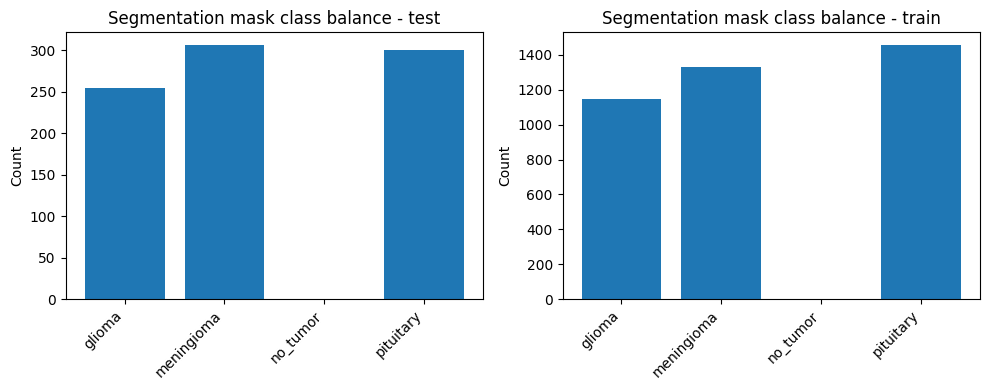

In [ ]:
cls_df = df[(df["task"]=="classification") & (df["is_mask"]==False)].copy()
seg_mask_df = df[(df["task"]=="segmentation") & (df["is_mask"]==True)].copy()

print("\nClassification split counts:")
print(cls_df["split"].value_counts())

print("\nSegmentation mask split counts:")
print(seg_mask_df["split"].value_counts())

def plot_class_distribution(data, title):
    splits = sorted(data["split"].dropna().unique().tolist())
    fig, axes = plt.subplots(1, len(splits), figsize=(5*len(splits), 4))
    if len(splits) == 1:
        axes = [axes]
    for ax, sp in zip(axes, splits):
        sub = data[data["split"]==sp]
        counts = sub["tumor_label"].value_counts().reindex(class_names, fill_value=0)
        ax.bar(counts.index, counts.values)
        ax.set_title(f"{title} - {sp}")
        ax.set_xticklabels(counts.index, rotation=45, ha="right")
        ax.set_ylabel("Count")
    plt.tight_layout()
    plt.show()

plot_class_distribution(cls_df, "Classification class balance")
plot_class_distribution(seg_mask_df, "Segmentation mask class balance")


In [ ]:
HYPERPARAMS = {
    "img_size": (256,256),
    "batch_size": 8,
    "epochs_seg": 10,
    "epochs_cls": 10,
    "learning_rate": 1e-3,
    "optimizer": "Adam",
    "seg_loss": "0.5*BCEWithLogits + 0.5*DiceLoss",
    "cls_loss": "CrossEntropyLoss",
    "mask_threshold": 0.5,
    "weight_decay": 0.0,
}
for k,v in HYPERPARAMS.items():
    print(f"{k}: {v}")


img_size: (256, 256)
batch_size: 8
epochs_seg: 10
epochs_cls: 10
learning_rate: 0.001
optimizer: Adam
seg_loss: 0.5*BCEWithLogits + 0.5*DiceLoss
cls_loss: CrossEntropyLoss
mask_threshold: 0.5
weight_decay: 0.0


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import cv2
import numpy as np

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

IMG_SIZE = HYPERPARAMS["img_size"]
BATCH_SIZE = HYPERPARAMS["batch_size"]

# ---- build classification split ----
df_cls_train = cls_df[cls_df["split"]=="train"].copy()
df_cls_test  = cls_df[cls_df["split"]=="test"].copy()
df_cls_val   = cls_df[cls_df["split"].isin(["val","valid","validation"])].copy()

if len(df_cls_val)==0 and len(df_cls_train)>0:
    df_cls_train, df_cls_val = train_test_split(
        df_cls_train, test_size=0.2, random_state=42,
        stratify=df_cls_train["tumor_label"] if "tumor_label" in df_cls_train.columns else None
    )

print("Cls train/val/test:", len(df_cls_train), len(df_cls_val), len(df_cls_test))

# ---- dataset ----
def read_gray_01(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None: raise FileNotFoundError(path)
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    return img.astype(np.float32)/255.0

class ClassificationDataset(Dataset):
    def __init__(self, df_cls):
        self.df = df_cls.reset_index(drop=True)

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = DATA_ROOT / fix_relpath(row["relative_path"])
        img01 = read_gray_01(img_path)
        x = torch.from_numpy(img01)[None,:,:]  # (1,H,W)
        y = torch.tensor(label2id[row["tumor_label"]], dtype=torch.long)
        return x, y

train_loader = DataLoader(ClassificationDataset(df_cls_train), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader   = DataLoader(ClassificationDataset(df_cls_val),   batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader  = DataLoader(ClassificationDataset(df_cls_test),  batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

# ---- simple encoder+GAP classifier ----
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x): return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)
    def forward(self, x): return self.conv(self.pool(x))

class EncoderClassifier(nn.Module):
    def __init__(self, in_channels=1, num_classes=4, base=32, dropout=0.2):
        super().__init__()
        self.inc   = DoubleConv(in_channels, base)
        self.down1 = Down(base, base*2)
        self.down2 = Down(base*2, base*4)
        self.down3 = Down(base*4, base*8)
        self.bottleneck = DoubleConv(base*8, base*16)
        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(base*16, base*8),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(base*8, num_classes)
        )
    def forward(self, x):
        x = self.inc(x)
        x = self.down1(x)
        x = self.down2(x)
        x = self.down3(x)
        x = self.bottleneck(x)
        return self.head(self.gap(x))

cls_model = EncoderClassifier(in_channels=1, num_classes=len(class_names), base=32).to(device)

ce = nn.CrossEntropyLoss()
opt = torch.optim.Adam(cls_model.parameters(), lr=HYPERPARAMS["learning_rate"], weight_decay=HYPERPARAMS["weight_decay"])

def train_cls_epoch(model, loader):
    model.train()
    total_loss=0
    yT=[]; yP=[]
    for x,y in tqdm(loader, leave=False):
        x,y = x.to(device), y.to(device)
        opt.zero_grad()
        logits = model(x)
        loss = ce(logits, y)
        loss.backward()
        opt.step()
        total_loss += loss.item()*x.size(0)
        yT.extend(y.cpu().numpy().tolist())
        yP.extend(torch.argmax(logits,1).cpu().numpy().tolist())
    return total_loss/len(loader.dataset), accuracy_score(yT,yP)

@torch.no_grad()
def eval_cls_epoch(model, loader):
    model.eval()
    total_loss=0
    yT=[]; yP=[]
    for x,y in tqdm(loader, leave=False):
        x,y = x.to(device), y.to(device)
        logits = model(x)
        loss = ce(logits, y)
        total_loss += loss.item()*x.size(0)
        yT.extend(y.cpu().numpy().tolist())
        yP.extend(torch.argmax(logits,1).cpu().numpy().tolist())
    return total_loss/len(loader.dataset), accuracy_score(yT,yP)

hist = {"tr_loss":[], "va_loss":[], "tr_acc":[], "va_acc":[]}
for ep in range(1, HYPERPARAMS["epochs_cls"]+1):
    trL, trA = train_cls_epoch(cls_model, train_loader)
    vaL, vaA = eval_cls_epoch(cls_model, val_loader)
    hist["tr_loss"].append(trL); hist["va_loss"].append(vaL)
    hist["tr_acc"].append(trA);  hist["va_acc"].append(vaA)
    print(f"Epoch {ep}: train_loss={trL:.4f} acc={trA:.3f} | val_loss={vaL:.4f} acc={vaA:.3f}")

# curves
plt.figure(figsize=(6,4))
plt.plot(hist["tr_loss"], label="train_loss")
plt.plot(hist["va_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Classification Loss"); plt.legend(); plt.show()

plt.figure(figsize=(6,4))
plt.plot(hist["tr_acc"], label="train_acc")
plt.plot(hist["va_acc"], label="val_acc")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.title("Classification Accuracy"); plt.legend(); plt.show()


Device: cuda


NameError: name 'HYPERPARAMS' is not defined

In [ ]:
import numpy as np
import cv2
import torch
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# ----------------------------
# 0) Pick your trained seg model safely
# ----------------------------
if "model_attn" in globals():
    seg_model = model_attn
elif "model" in globals():
    seg_model = model
else:
    print("❌ No segmentation model found. Available names containing 'model':")
    print([k for k in globals().keys() if "model" in k.lower()])
    raise NameError("Define your trained segmentation model first (e.g., model_attn or model).")

seg_model = seg_model.to(device)  # device must already exist (cuda/cpu)
seg_model.eval()

# ----------------------------
# 1) Build segmentation dfs (defines seg_df to fix your previous error)
# ----------------------------
seg_df = df[(df["task"]=="segmentation") & (df["is_mask"]==True)].copy()

df_seg_train = seg_df[seg_df["split"]=="train"].copy()
df_seg_test  = seg_df[seg_df["split"]=="test"].copy()
df_seg_val   = seg_df[seg_df["split"].isin(["val","valid","validation"])].copy()

# create val if missing
if len(df_seg_val)==0 and len(df_seg_train)>0:
    df_seg_train, df_seg_val = train_test_split(
        df_seg_train, test_size=0.2, random_state=42,
        stratify=df_seg_train["tumor_label"] if "tumor_label" in df_seg_train.columns else None
    )

print("Seg masks train/val/test:", len(df_seg_train), len(df_seg_val), len(df_seg_test))

# ----------------------------
# 2) Preprocess helpers
# ----------------------------
TH = HYPERPARAMS["mask_threshold"]
IMG_SIZE = HYPERPARAMS["img_size"]

def fix_relpath(p):
    return str(p).replace("\\", "/")

def read_gray_01(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {path}")
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    return img.astype(np.float32)/255.0

def read_mask01(path):
    m = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise FileNotFoundError(f"Cannot read mask: {path}")
    m = cv2.resize(m, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
    return (m>0).astype(np.uint8)

# ----------------------------
# 3) Metrics function: Dice, mIoU, PixelAcc
# ----------------------------
@torch.no_grad()
def eval_seg_df(seg_model, df_masks, thresh=0.5):
    seg_model.eval()
    dices=[]; ious=[]; pix=[]

    for _, row in tqdm(df_masks.iterrows(), total=len(df_masks), leave=False):
        img_path  = DATA_ROOT / fix_relpath(row["linked_image"])
        mask_path = DATA_ROOT / fix_relpath(row["relative_path"])

        img01 = read_gray_01(img_path)
        gt    = read_mask01(mask_path)

        x = torch.from_numpy(img01)[None,None,:,:].to(device)

        out = seg_model(x)
        seg_logits = out[0] if isinstance(out,(tuple,list)) else out

        prob = torch.sigmoid(seg_logits)[0,0].cpu().numpy()
        pred = (prob>=thresh).astype(np.uint8)

        inter = np.sum((pred==1) & (gt==1))
        ps = np.sum(pred==1)
        gs = np.sum(gt==1)

        dice = (2*inter + 1e-7) / (ps + gs + 1e-7)
        iou  = (inter + 1e-7) / (ps + gs - inter + 1e-7)
        pixacc = np.mean(pred == gt)

        dices.append(dice); ious.append(iou); pix.append(pixacc)

    return {
        "Dice": float(np.mean(dices)),
        "mIoU": float(np.mean(ious)),
        "PixelAcc": float(np.mean(pix))
    }

# ----------------------------
# 4) Run metrics on train/val/test
# ----------------------------
seg_train_m = eval_seg_df(seg_model, df_seg_train, TH)
seg_val_m   = eval_seg_df(seg_model, df_seg_val, TH)
seg_test_m  = eval_seg_df(seg_model, df_seg_test, TH)

print("\nSegmentation Metrics:")
print("Train:", seg_train_m)
print("Val  :", seg_val_m)
print("Test :", seg_test_m)


Seg masks train/val/test: 3146 787 860



Segmentation Metrics:
Train: {'Dice': 0.7736742181373721, 'mIoU': 0.6681545486027487, 'PixelAcc': 0.9926281715000199}
Val  : {'Dice': 0.7378042704637942, 'mIoU': 0.6326012842918137, 'PixelAcc': 0.9916427980687142}
Test : {'Dice': 0.7509375331715021, 'mIoU': 0.6438657386450413, 'PixelAcc': 0.9909901286280433}



Classification Metrics:
Train: {'Accuracy': 0.6528, 'Precision': 0.767, 'Recall': 0.6626, 'F1': 0.655}
Val  : {'Accuracy': 0.617, 'Precision': 0.7477, 'Recall': 0.6272, 'F1': 0.6159}
Test : {'Accuracy': 0.602, 'Precision': 0.7314, 'Recall': 0.6506, 'F1': 0.6094}


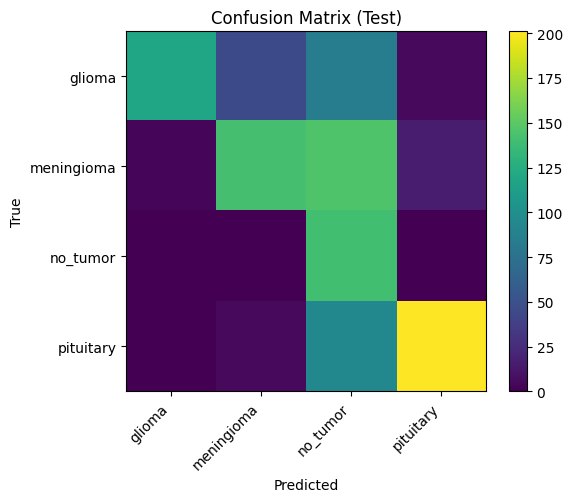

In [ ]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, accuracy_score

@torch.no_grad()
def eval_cls_df(cls_model, df_cls):
    cls_model.eval()
    yT=[]; yP=[]
    for _, row in tqdm(df_cls.iterrows(), total=len(df_cls), leave=False):
        img_path = DATA_ROOT / fix_relpath(row["relative_path"])
        img01 = read_gray_01(img_path)
        x = torch.from_numpy(img01)[None,None,:,:].to(device)

        logits = cls_model(x)
        pred = int(torch.argmax(logits, dim=1).item())
        true = label2id[row["tumor_label"]]
        yT.append(true); yP.append(pred)

    acc = accuracy_score(yT,yP)
    prec, rec, f1, _ = precision_recall_fscore_support(yT,yP,average="macro",zero_division=0)
    cm = confusion_matrix(yT,yP,labels=list(range(len(class_names))))
    return {"Accuracy":acc,"Precision":prec,"Recall":rec,"F1":f1,"CM":cm}

cls_train_m = eval_cls_df(cls_model, df_cls_train)
cls_val_m   = eval_cls_df(cls_model, df_cls_val)
cls_test_m  = eval_cls_df(cls_model, df_cls_test)

print("\nClassification Metrics:")
print("Train:", {k: round(v,4) for k,v in cls_train_m.items() if k!="CM"})
print("Val  :", {k: round(v,4) for k,v in cls_val_m.items() if k!="CM"})
print("Test :", {k: round(v,4) for k,v in cls_test_m.items() if k!="CM"})

cm = cls_test_m["CM"]
plt.figure(figsize=(6,5))
plt.imshow(cm)
plt.title("Confusion Matrix (Test)")
plt.xticks(range(len(class_names)), class_names, rotation=45, ha="right")
plt.yticks(range(len(class_names)), class_names)
plt.colorbar()
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout()
plt.show()


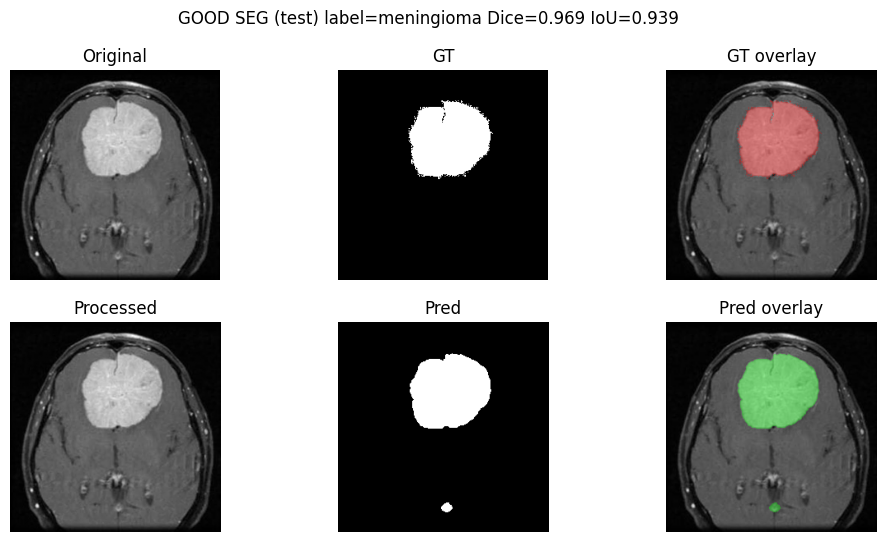

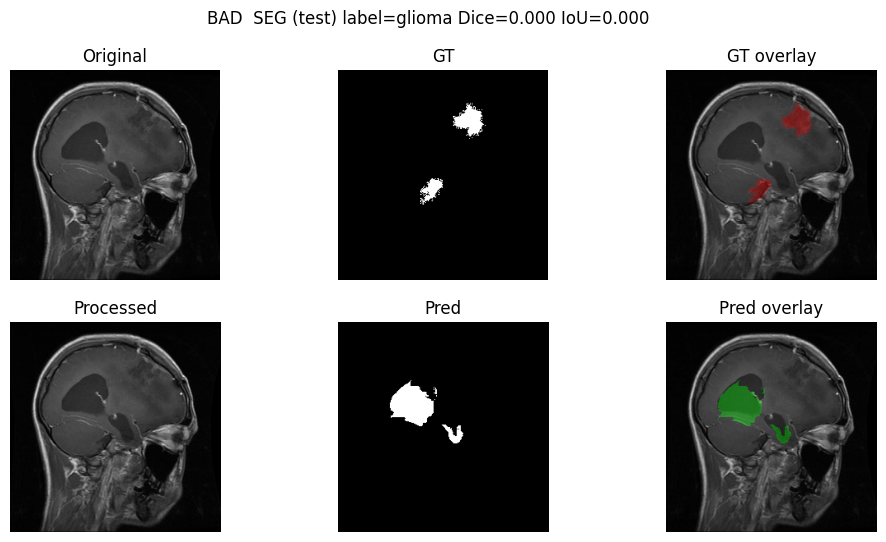

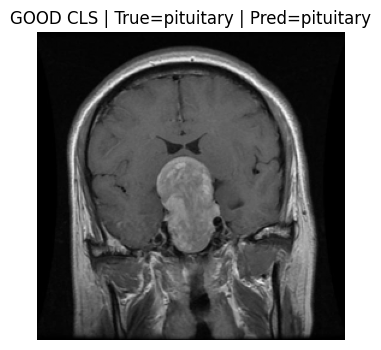

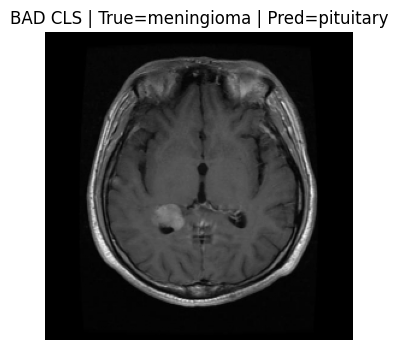

In [ ]:
def overlay(img01, mask01, color="red", alpha=0.35):
    rgb = np.stack([img01]*3, axis=-1)
    ov = rgb.copy()
    if color=="red":   ov[mask01==1] = [1,0,0]
    if color=="green": ov[mask01==1] = [0,1,0]
    return (1-alpha)*rgb + alpha*ov

def show_seg_panel(img01, gt, pred, title=""):
    plt.figure(figsize=(12,6))
    plt.suptitle(title, y=0.98)
    plt.subplot(2,3,1); plt.imshow(img01,cmap="gray"); plt.title("Original"); plt.axis("off")
    plt.subplot(2,3,2); plt.imshow(gt,cmap="gray"); plt.title("GT"); plt.axis("off")
    plt.subplot(2,3,3); plt.imshow(overlay(img01,gt,"red")); plt.title("GT overlay"); plt.axis("off")
    plt.subplot(2,3,4); plt.imshow(img01,cmap="gray"); plt.title("Processed"); plt.axis("off")
    plt.subplot(2,3,5); plt.imshow(pred,cmap="gray"); plt.title("Pred"); plt.axis("off")
    plt.subplot(2,3,6); plt.imshow(overlay(img01,pred,"green")); plt.title("Pred overlay"); plt.axis("off")
    plt.show()

def dice_iou(pred, gt):
    inter = np.sum((pred==1)&(gt==1))
    ps = np.sum(pred==1); gs = np.sum(gt==1)
    dice = (2*inter + 1e-7)/(ps+gs+1e-7)
    iou  = (inter + 1e-7)/(ps+gs-inter+1e-7)
    return dice, iou

@torch.no_grad()
def good_bad_seg(seg_model, df_masks, thresh=0.5, n_scan=200):
    seg_model.eval()
    scores=[]
    sample_df = df_masks.sample(min(n_scan,len(df_masks)), random_state=np.random.randint(0,99999))
    for _, row in sample_df.iterrows():
        img_path  = DATA_ROOT / fix_relpath(row["linked_image"])
        mask_path = DATA_ROOT / fix_relpath(row["relative_path"])
        img01 = read_gray_01(img_path)
        gt = read_mask01(mask_path)

        x = torch.from_numpy(img01)[None,None,:,:].to(device)
        out = seg_model(x)
        seg_logits = out[0] if isinstance(out,(tuple,list)) else out
        pred = (torch.sigmoid(seg_logits)[0,0].cpu().numpy() >= thresh).astype(np.uint8)

        d,i = dice_iou(pred, gt)
        scores.append((i,d,img01,gt,pred,row["tumor_label"]))
    scores.sort(key=lambda x: x[0])
    return scores[-1], scores[0]  # best, worst

best, worst = good_bad_seg(seg_model, df_seg_test, TH, n_scan=200)
iou_g,dice_g,img_g,gt_g,pred_g,lbl_g = best
iou_b,dice_b,img_b,gt_b,pred_b,lbl_b = worst

show_seg_panel(img_g, gt_g, pred_g, title=f"GOOD SEG (test) label={lbl_g} Dice={dice_g:.3f} IoU={iou_g:.3f}")
show_seg_panel(img_b, gt_b, pred_b, title=f"BAD  SEG (test) label={lbl_b} Dice={dice_b:.3f} IoU={iou_b:.3f}")

@torch.no_grad()
def good_bad_cls(cls_model, df_cls, n_scan=300):
    cls_model.eval()
    good=None; bad=None
    sample_df = df_cls.sample(min(n_scan,len(df_cls)), random_state=np.random.randint(0,99999))
    for _, row in sample_df.iterrows():
        img_path = DATA_ROOT / fix_relpath(row["relative_path"])
        img01 = read_gray_01(img_path)
        x = torch.from_numpy(img01)[None,None,:,:].to(device)

        logits = cls_model(x)
        pred = int(torch.argmax(logits,1).item())
        true = label2id[row["tumor_label"]]

        if pred==true and good is None:
            good=(img01,true,pred)
        if pred!=true and bad is None:
            bad=(img01,true,pred)
        if good and bad:
            break

    for tag, ex in [("GOOD CLS",good),("BAD CLS",bad)]:
        if ex is None:
            print("No example:", tag); continue
        img01,t,p = ex
        plt.figure(figsize=(4,4))
        plt.imshow(img01,cmap="gray")
        plt.title(f"{tag} | True={id2label[t]} | Pred={id2label[p]}")
        plt.axis("off")
        plt.show()

good_bad_cls(cls_model, df_cls_test)


Demo image: /content/brisc2025/brisc2025/segmentation_task/test/images/brisc2025_test_00513_me_sa_t1.jpg


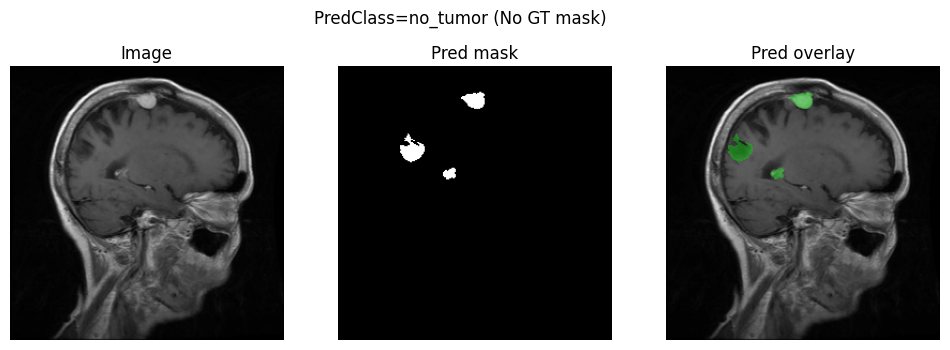

In [ ]:
def find_gt_mask_if_exists(img_path):
    # matches masks using linked_image in manifest
    s = str(img_path)
    if "/brisc2025/" not in s:
        return None
    rel = s.split("/brisc2025/")[1]
    rel_back = rel.replace("/", "\\")

    cand = df[(df["task"]=="segmentation") & (df["is_mask"]==True) & (df["linked_image"]==rel_back)]
    if len(cand)==0:
        return None
    row = cand.iloc[0]
    mask_path = DATA_ROOT / fix_relpath(row["relative_path"])
    return read_mask01(mask_path)

@torch.no_grad()
def demo_any_image(img_path):
    img_path = Path(img_path)
    img01 = read_gray_01(img_path)
    x = torch.from_numpy(img01)[None,None,:,:].to(device)

    # classification
    logits = cls_model(x)
    pred_id = int(torch.argmax(logits,1).item())
    pred_name = id2label[pred_id]

    # segmentation
    out = seg_model(x)
    seg_logits = out[0] if isinstance(out,(tuple,list)) else out
    prob = torch.sigmoid(seg_logits)[0,0].cpu().numpy()
    pred_mask = (prob>=TH).astype(np.uint8)

    gt = find_gt_mask_if_exists(img_path)
    if gt is not None:
        d,i = dice_iou(pred_mask, gt)
        title = f"PredClass={pred_name} | Dice={d:.3f} | IoU={i:.3f}"
        show_seg_panel(img01, gt, pred_mask, title=title)
    else:
        plt.figure(figsize=(12,4))
        plt.suptitle(f"PredClass={pred_name} (No GT mask)", y=0.98)
        plt.subplot(1,3,1); plt.imshow(img01,cmap="gray"); plt.title("Image"); plt.axis("off")
        plt.subplot(1,3,2); plt.imshow(pred_mask,cmap="gray"); plt.title("Pred mask"); plt.axis("off")
        plt.subplot(1,3,3); plt.imshow(overlay(img01,pred_mask,"green")); plt.title("Pred overlay"); plt.axis("off")
        plt.show()

# demo on a random test segmentation image
row = df_seg_test.sample(1, random_state=np.random.randint(0,99999)).iloc[0]
demo_img = DATA_ROOT / fix_relpath(row["linked_image"])
print("Demo image:", demo_img)
demo_any_image(demo_img)


# Task 03

In [ ]:
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# --- make seg_df + splits ---
seg_df = df[(df["task"]=="segmentation") & (df["is_mask"]==True)].copy()

seg_train = seg_df[seg_df["split"]=="train"].copy()
seg_val   = seg_df[seg_df["split"].isin(["val","valid","validation"])].copy()
seg_test  = seg_df[seg_df["split"]=="test"].copy()

if len(seg_val)==0 and len(seg_train)>0:
    seg_train, seg_val = train_test_split(
        seg_train, test_size=0.2, random_state=42,
        stratify=seg_train["tumor_label"] if "tumor_label" in seg_train.columns else None
    )

IMG_SIZE = (256,256)  # keep same as your model input

def read_gray_01(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None: raise FileNotFoundError(path)
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    return img.astype(np.float32)/255.0

def read_mask01(path):
    m = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if m is None: raise FileNotFoundError(path)
    m = cv2.resize(m, IMG_SIZE, interpolation=cv2.INTER_NEAREST)
    return (m>0).astype(np.float32)   # ✅ 0/1 float for BCE

class SegDataset(Dataset):
    def __init__(self, df_masks):
        self.df = df_masks.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path  = DATA_ROOT / fix_relpath(row["linked_image"])
        mask_path = DATA_ROOT / fix_relpath(row["relative_path"])

        img  = read_gray_01(img_path)
        mask = read_mask01(mask_path)

        x = torch.from_numpy(img)[None,:,:]   # (1,H,W)
        y = torch.from_numpy(mask)[None,:,:]  # (1,H,W)

        return x, y

seg_train_loader = DataLoader(SegDataset(seg_train), batch_size=8, shuffle=True, num_workers=2)
seg_val_loader   = DataLoader(SegDataset(seg_val),   batch_size=8, shuffle=False, num_workers=2)

print("seg_train_loader batches:", len(seg_train_loader))
print("seg_val_loader batches  :", len(seg_val_loader))


seg_train_loader batches: 394
seg_val_loader batches  : 99


In [ ]:
import torch
import torch.nn as nn

seg_ce = nn.BCEWithLogitsLoss()
optimizer_seg = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_seg_epoch_ce(model, loader):
    model.train()
    total = 0
    for x, ymask in loader:  # ✅ only 2 values now
        x, ymask = x.to(device), ymask.to(device)

        optimizer_seg.zero_grad()
        seg_logits, _ = model(x)          # model returns (seg_logits, cls_logits)
        loss = seg_ce(seg_logits, ymask)

        loss.backward()
        optimizer_seg.step()
        total += loss.item() * x.size(0)

    return total / len(loader.dataset)

@torch.no_grad()
def eval_seg_epoch_ce(model, loader):
    model.eval()
    total = 0
    for x, ymask in loader:  # ✅ only 2 values now
        x, ymask = x.to(device), ymask.to(device)
        seg_logits, _ = model(x)
        loss = seg_ce(seg_logits, ymask)
        total += loss.item() * x.size(0)

    return total / len(loader.dataset)

EPOCHS_SEG = 10
seg_tr, seg_va = [], []

for ep in range(1, EPOCHS_SEG + 1):
    tr = train_seg_epoch_ce(model, seg_train_loader)
    va = eval_seg_epoch_ce(model, seg_val_loader)
    seg_tr.append(tr); seg_va.append(va)
    print(f"[SEG-CE] Epoch {ep}: train_loss={tr:.4f} val_loss={va:.4f}")


[SEG-CE] Epoch 1: train_loss=0.1888 val_loss=0.0806
[SEG-CE] Epoch 2: train_loss=0.0564 val_loss=0.0546
[SEG-CE] Epoch 3: train_loss=0.0403 val_loss=0.0432
[SEG-CE] Epoch 4: train_loss=0.0341 val_loss=0.0316
[SEG-CE] Epoch 5: train_loss=0.0294 val_loss=0.0319
[SEG-CE] Epoch 6: train_loss=0.0266 val_loss=0.0290
[SEG-CE] Epoch 7: train_loss=0.0233 val_loss=0.0548
[SEG-CE] Epoch 8: train_loss=0.0238 val_loss=0.0421
[SEG-CE] Epoch 9: train_loss=0.0204 val_loss=0.0244
[SEG-CE] Epoch 10: train_loss=0.0193 val_loss=0.0220


In [ ]:
import numpy as np
import cv2
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

# 1) build classification dataframe
cls_df = df[(df["task"]=="classification") & (df["is_mask"]==False)].copy()

cls_train = cls_df[cls_df["split"]=="train"].copy()
cls_val   = cls_df[cls_df["split"].isin(["val","valid","validation"])].copy()

# if no val split exists, create 20%
if len(cls_val)==0 and len(cls_train)>0:
    cls_train, cls_val = train_test_split(
        cls_train, test_size=0.2, random_state=42,
        stratify=cls_train["tumor_label"] if "tumor_label" in cls_train.columns else None
    )

IMG_SIZE = (256,256)  # must match your model input

def read_gray_01(path):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot read image: {path}")
    img = cv2.resize(img, IMG_SIZE, interpolation=cv2.INTER_AREA)
    return img.astype(np.float32)/255.0

class ClsDataset(Dataset):
    def __init__(self, df_cls):
        self.df = df_cls.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = DATA_ROOT / fix_relpath(row["relative_path"])
        img01 = read_gray_01(img_path)
        x = torch.from_numpy(img01)[None,:,:]  # (1,H,W)
        y = torch.tensor(label2id[row["tumor_label"]], dtype=torch.long)
        return x, y

cls_train_loader = DataLoader(ClsDataset(cls_train), batch_size=16, shuffle=True, num_workers=2)
cls_val_loader   = DataLoader(ClsDataset(cls_val),   batch_size=16, shuffle=False, num_workers=2)

print("CLS train batches:", len(cls_train_loader))
print("CLS val batches  :", len(cls_val_loader))


CLS train batches: 250
CLS val batches  : 63


In [ ]:
ce = nn.CrossEntropyLoss()

optimizer_cls = torch.optim.Adam(model.parameters(), lr=1e-3)

def train_cls_epoch(model, loader):
    model.train()
    total = 0
    yT=[]; yP=[]
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer_cls.zero_grad()
        _, cls_logits = model(x)
        loss = ce(cls_logits, y)
        loss.backward()
        optimizer_cls.step()

        total += loss.item()*x.size(0)
        yT.extend(y.cpu().numpy().tolist())
        yP.extend(torch.argmax(cls_logits,1).cpu().numpy().tolist())
    acc = accuracy_score(yT,yP)
    return total/len(loader.dataset), acc

@torch.no_grad()
def eval_cls_epoch(model, loader):
    model.eval()
    total = 0
    yT=[]; yP=[]
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        _, cls_logits = model(x)
        loss = ce(cls_logits, y)

        total += loss.item()*x.size(0)
        yT.extend(y.cpu().numpy().tolist())
        yP.extend(torch.argmax(cls_logits,1).cpu().numpy().tolist())
    acc = accuracy_score(yT,yP)
    return total/len(loader.dataset), acc

cls_trL, cls_vaL, cls_trA, cls_vaA = [], [], [], []
EPOCHS_CLS = 10
for ep in range(1, EPOCHS_CLS+1):
    trL, trA = train_cls_epoch(model, cls_train_loader)
    vaL, vaA = eval_cls_epoch(model, cls_val_loader)
    cls_trL.append(trL); cls_vaL.append(vaL)
    cls_trA.append(trA); cls_vaA.append(vaA)
    print(f"[CLS] Epoch {ep}: tr_loss={trL:.4f} tr_acc={trA:.3f} | va_loss={vaL:.4f} va_acc={vaA:.3f}")


[CLS] Epoch 1: tr_loss=0.7177 tr_acc=0.702 | va_loss=1.7498 va_acc=0.450
[CLS] Epoch 2: tr_loss=0.4713 tr_acc=0.827 | va_loss=0.6240 va_acc=0.742
[CLS] Epoch 3: tr_loss=0.4117 tr_acc=0.848 | va_loss=0.3088 va_acc=0.875
[CLS] Epoch 4: tr_loss=0.3578 tr_acc=0.864 | va_loss=0.3234 va_acc=0.891
[CLS] Epoch 5: tr_loss=0.3134 tr_acc=0.885 | va_loss=0.2609 va_acc=0.910
[CLS] Epoch 6: tr_loss=0.2763 tr_acc=0.898 | va_loss=0.3671 va_acc=0.864
[CLS] Epoch 7: tr_loss=0.2352 tr_acc=0.911 | va_loss=0.2918 va_acc=0.909
[CLS] Epoch 8: tr_loss=0.2276 tr_acc=0.919 | va_loss=0.3760 va_acc=0.850
[CLS] Epoch 9: tr_loss=0.2036 tr_acc=0.919 | va_loss=0.2837 va_acc=0.901
[CLS] Epoch 10: tr_loss=0.1899 tr_acc=0.930 | va_loss=0.4186 va_acc=0.829



===== TRAIN =====
[Segmentation]
  mIoU       : 0.6682
  Dice       : 0.7737
  PixelAcc   : 0.9926
[Classification]
  Accuracy        : 0.6528
  Precision(macro): 0.7670
  Recall(macro)   : 0.6626
  F1(macro)       : 0.6550

===== VAL =====
[Segmentation]
  mIoU       : 0.6326
  Dice       : 0.7378
  PixelAcc   : 0.9916
[Classification]
  Accuracy        : 0.6170
  Precision(macro): 0.7477
  Recall(macro)   : 0.6272
  F1(macro)       : 0.6159

===== TEST =====


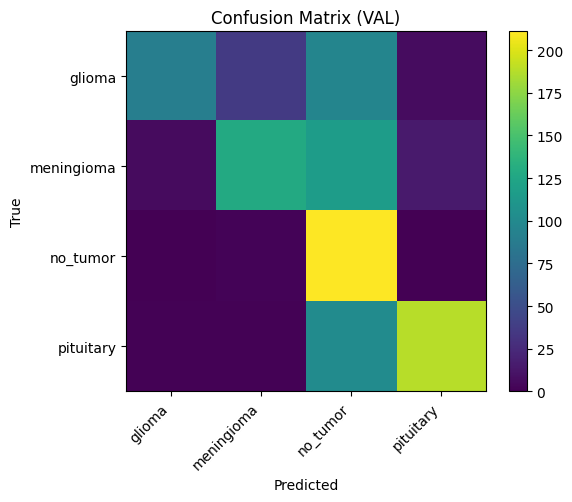

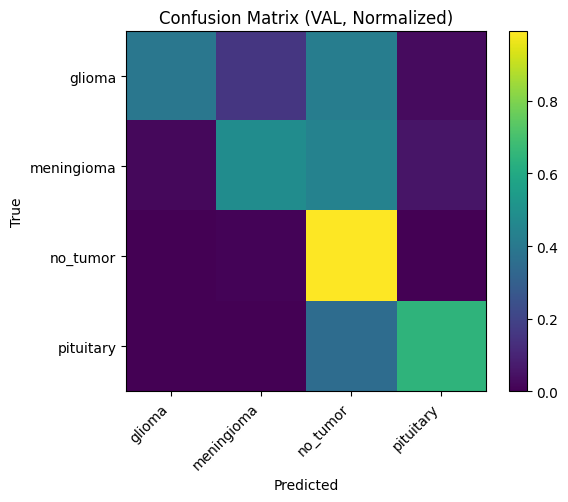

In [ ]:
# =========================
# TASK 4 — Evaluation Metrics
# Segmentation: mIoU, Dice, Pixel accuracy
# Classification: Accuracy, Precision/Recall/F1, Confusion Matrix
# Copy-paste this whole cell
# =========================

from __future__ import annotations

from typing import Any, Dict, List, Optional, Tuple
import numpy as np
import torch
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    confusion_matrix,
)

# -------------------------
# STEP 1) Device + pick models
# -------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# If you trained a single multitask model named `model`, this will work.
# If you trained separate models `seg_model` and `cls_model`, those will be used.
seg_model = globals().get("seg_model", None) or globals().get("model", None)
cls_model = globals().get("cls_model", None) or globals().get("model", None)

if seg_model is None and cls_model is None:
    raise RuntimeError(
        "No model found. Expected `model` (multitask) or `seg_model`/`cls_model` in globals()."
    )

if seg_model is not None:
    seg_model = seg_model.to(DEVICE)
if cls_model is not None:
    cls_model = cls_model.to(DEVICE)

# -------------------------
# STEP 2) Class mapping (label2id, id2label, class_names)
# -------------------------
def _get_class_mapping() -> Tuple[Dict[str, int], Dict[int, str], List[str]]:
    if "label2id" in globals() and isinstance(globals()["label2id"], dict) and len(globals()["label2id"]) > 0:
        label2id = dict(globals()["label2id"])
        id2label = {v: k for k, v in label2id.items()}
        class_names = [id2label[i] for i in range(len(id2label))]
        return label2id, id2label, class_names

    if "df" in globals() and "tumor_label" in globals()["df"].columns:
        labs = sorted([str(x) for x in globals()["df"]["tumor_label"].dropna().unique().tolist()])
        label2id = {lab: i for i, lab in enumerate(labs)}
        id2label = {i: lab for lab, i in label2id.items()}
        class_names = labs
        return label2id, id2label, class_names

    raise RuntimeError("Could not build class mapping. Provide `label2id` or a `df` with column `tumor_label`.")

label2id, id2label, class_names = _get_class_mapping()

# -------------------------
# STEP 3) Helper: extract outputs from different model styles
# -------------------------
def _extract_outputs(model_out: Any) -> Tuple[Optional[torch.Tensor], Optional[torch.Tensor]]:
    """
    Returns (seg_tensor, cls_tensor) if found.
    Supports:
      - multitask tuple: (seg_logits, cls_logits)
      - dict outputs with keys like seg/mask/cls/logits
      - single tensor (3D/4D -> seg, 2D -> cls)
    """
    seg, cls = None, None

    if isinstance(model_out, (tuple, list)) and len(model_out) >= 2:
        a, b = model_out[0], model_out[1]
        if isinstance(a, torch.Tensor) and a.dim() >= 3:
            seg = a
            cls = b if isinstance(b, torch.Tensor) else None
        elif isinstance(b, torch.Tensor) and b.dim() >= 3:
            seg = b
            cls = a if isinstance(a, torch.Tensor) else None
        else:
            seg = a if isinstance(a, torch.Tensor) else None
            cls = b if isinstance(b, torch.Tensor) else None

    elif isinstance(model_out, dict):
        for k in ("seg", "mask", "seg_logits", "segmentation", "logits_seg"):
            if k in model_out and isinstance(model_out[k], torch.Tensor):
                seg = model_out[k]
                break
        for k in ("cls", "class", "cls_logits", "classification", "logits_cls"):
            if k in model_out and isinstance(model_out[k], torch.Tensor):
                cls = model_out[k]
                break

    elif isinstance(model_out, torch.Tensor):
        if model_out.dim() >= 3:
            seg = model_out
        elif model_out.dim() == 2:
            cls = model_out

    return seg, cls

# -------------------------
# STEP 4) Segmentation metrics (binary)
# -------------------------
def _ensure_n1hw(x: torch.Tensor) -> torch.Tensor:
    if x.dim() == 2:   # (H,W)
        return x.unsqueeze(0).unsqueeze(0)
    if x.dim() == 3:   # (N,H,W) or (1,H,W)
        return x.unsqueeze(1)
    if x.dim() == 4:   # (N,1,H,W) or (N,C,H,W)
        return x
    raise ValueError(f"Expected 2D/3D/4D tensor, got {tuple(x.shape)}")

def _to_prob_if_logits(x: torch.Tensor) -> torch.Tensor:
    x = x.float()
    if x.min() < 0.0 or x.max() > 1.0:
        return torch.sigmoid(x)
    return x

def _binarize(x: torch.Tensor, threshold: float = 0.5) -> torch.Tensor:
    x = _ensure_n1hw(x)
    x = _to_prob_if_logits(x)
    return (x >= float(threshold)).float()

def dice_coefficient(pred: torch.Tensor, targ: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    p = _binarize(pred, 0.5).flatten(1)
    t = _binarize(targ, 0.5).flatten(1)
    inter = (p * t).sum(dim=1)
    den = p.sum(dim=1) + t.sum(dim=1)
    return (2.0 * inter + eps) / (den + eps)

def iou_score(pred: torch.Tensor, targ: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    p = _binarize(pred, 0.5).flatten(1)
    t = _binarize(targ, 0.5).flatten(1)
    inter = (p * t).sum(dim=1)
    union = p.sum(dim=1) + t.sum(dim=1) - inter
    return (inter + eps) / (union + eps)

def pixel_accuracy(pred: torch.Tensor, targ: torch.Tensor) -> torch.Tensor:
    p = _binarize(pred, 0.5)
    t = _binarize(targ, 0.5)
    return (p == t).float().flatten(1).mean(dim=1)

@torch.no_grad()
def evaluate_segmentation(
    model: torch.nn.Module,
    loader,
    device: str = DEVICE,
    threshold: float = 0.5,
) -> Dict[str, float]:
    model.eval()
    device_t = torch.device(device)

    dice_vals: List[float] = []
    iou_vals: List[float] = []
    pix_vals: List[float] = []

    for x, ymask in loader:
        x = x.to(device_t)
        ymask = ymask.to(device_t)

        out = model(x)
        seg_out, _ = _extract_outputs(out)
        if seg_out is None:
            raise RuntimeError("Segmentation output not found from model forward().")

        pred_bin = _binarize(seg_out, threshold)
        targ_bin = _binarize(ymask, 0.5)

        dice_vals.extend(dice_coefficient(pred_bin, targ_bin).cpu().tolist())
        iou_vals.extend(iou_score(pred_bin, targ_bin).cpu().tolist())
        pix_vals.extend(pixel_accuracy(pred_bin, targ_bin).cpu().tolist())

    return {
        "mIoU": float(np.mean(iou_vals)) if iou_vals else 0.0,
        "Dice": float(np.mean(dice_vals)) if dice_vals else 0.0,
        "PixelAcc": float(np.mean(pix_vals)) if pix_vals else 0.0,
    }

# -------------------------
# STEP 5) Classification metrics
# -------------------------
@torch.no_grad()
def evaluate_classification(
    model: torch.nn.Module,
    loader,
    device: str = DEVICE,
    class_names: Optional[List[str]] = None,
) -> Dict[str, Any]:
    model.eval()
    device_t = torch.device(device)

    y_true: List[int] = []
    y_pred: List[int] = []

    for x, y in loader:
        x = x.to(device_t)
        y = y.to(device_t)

        out = model(x)
        _, cls_out = _extract_outputs(out)
        if cls_out is None:
            if isinstance(out, torch.Tensor) and out.dim() == 2:
                cls_out = out
            else:
                raise RuntimeError("Classification output not found from model forward().")

        pred = torch.argmax(cls_out, dim=1)

        y_true.extend(y.detach().cpu().tolist())
        y_pred.extend(pred.detach().cpu().tolist())

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0
    )
    cm = confusion_matrix(y_true, y_pred)

    return {
        "Accuracy": float(acc),
        "Precision_macro": float(prec),
        "Recall_macro": float(rec),
        "F1_macro": float(f1),
        "ConfusionMatrix": cm,
        "ClassNames": class_names if class_names is not None else [str(i) for i in range(cm.shape[0])],
    }

def plot_confusion_matrix(cm: np.ndarray, labels: List[str], normalize: bool = False, title: str = "Confusion Matrix") -> None:
    cm = cm.astype(np.float32)
    if normalize:
        row_sum = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, row_sum, out=np.zeros_like(cm), where=row_sum != 0)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(labels))
    plt.xticks(tick_marks, labels, rotation=45, ha="right")
    plt.yticks(tick_marks, labels)
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()

# -------------------------
# STEP 6) Run evaluation on your loaders
# -------------------------
def _maybe_get(name: str):
    return globals().get(name, None)

seg_train_loader = _maybe_get("seg_train_loader")
seg_val_loader   = _maybe_get("seg_val_loader")
seg_test_loader  = _maybe_get("seg_test_loader")

cls_train_loader = _maybe_get("cls_train_loader")
cls_val_loader   = _maybe_get("cls_val_loader")
cls_test_loader  = _maybe_get("cls_test_loader")

def _print_block(title: str, seg_m: Optional[Dict[str, float]], cls_m: Optional[Dict[str, Any]]) -> None:
    print(f"\n===== {title} =====")
    if seg_m is not None:
        print("[Segmentation]")
        print(f"  mIoU       : {seg_m['mIoU']:.4f}")
        print(f"  Dice       : {seg_m['Dice']:.4f}")
        print(f"  PixelAcc   : {seg_m['PixelAcc']:.4f}")
    if cls_m is not None:
        print("[Classification]")
        print(f"  Accuracy        : {cls_m['Accuracy']:.4f}")
        print(f"  Precision(macro): {cls_m['Precision_macro']:.4f}")
        print(f"  Recall(macro)   : {cls_m['Recall_macro']:.4f}")
        print(f"  F1(macro)       : {cls_m['F1_macro']:.4f}")

def _eval_split(name: str):
    seg_m = None
    cls_m = None
    if seg_model is not None:
        loader = _maybe_get(f"seg_{name}_loader")
        if loader is not None:
            seg_m = evaluate_segmentation(seg_model, loader, device=DEVICE, threshold=float(globals().get("THRESH", 0.5)))
    if cls_model is not None:
        loader = _maybe_get(f"cls_{name}_loader")
        if loader is not None:
            cls_m = evaluate_classification(cls_model, loader, device=DEVICE, class_names=class_names)
    _print_block(name.upper(), seg_m, cls_m)
    return seg_m, cls_m

seg_tr_m, cls_tr_m = _eval_split("train")
seg_va_m, cls_va_m = _eval_split("val")
seg_te_m, cls_te_m = _eval_split("test")

# Plot confusion matrices if available
for split_name, cls_m in [("VAL", cls_va_m), ("TEST", cls_te_m)]:
    if cls_m is None:
        continue
    plot_confusion_matrix(cls_m["ConfusionMatrix"], cls_m["ClassNames"], normalize=False, title=f"Confusion Matrix ({split_name})")
    plot_confusion_matrix(cls_m["ConfusionMatrix"], cls_m["ClassNames"], normalize=True,  title=f"Confusion Matrix ({split_name}, Normalized)")





Split sizes: {'train': 4000, 'val': 1000, 'test': 1000}
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 124MB/s]
/tmp/ipython-input-2695065882.py:295: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipython-input-2695065882.py:301: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[efficientnet_b0 | baseline] ep 01/8  loss=0.4998  val acc=0.9460  val f1=0.9462


/tmp/ipython-input-2695065882.py:295: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipython-input-2695065882.py:301: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[efficientnet_b0 | baseline] ep 02/8  loss=0.2006  val acc=0.9610  val f1=0.9623


...

[simplecnn | clahe_zscore] ep 06/8  loss=1.2251  val acc=0.4980  val f1=0.4291


/tmp/ipython-input-2695065882.py:295: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
/tmp/ipython-input-2695065882.py:301: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):


[simplecnn | clahe_zscore] ep 07/8  loss=1.2129  val acc=0.4720  val f1=0.4061
Early stop: no val F1 improvement for 3 epochs.


,arch,preprocess,img_size,val_acc,val_f1,test_acc,test_f1,best_epoch
0,efficientnet_b0,baseline,"(224, 224)",0.989,0.989305,0.986,0.987759,7
1,efficientnet_b0,clahe_zscore,"(224, 224)",0.989,0.989192,0.984,0.985704,8
2,efficientnet_b0,clahe,"(224, 224)",0.989,0.989192,0.984,0.984830,7
3,resnet18,clahe,"(224, 224)",0.988,0.988335,0.986,0.986575,8
4,resnet18,clahe_zscore,"(224, 224)",0.988,0.988256,0.985,0.984310,6
5,resnet18,baseline,"(224, 224)",0.987,0.987405,0.986,0.987850,8
6,simplecnn,baseline,"(224, 224)",0.597,0.575063,0.516,0.490361,7
7,simplecnn,clahe,"(224, 224)",0.594,0.568676,0.518,0.497958,7
8,simplecnn,clahe_zscore,"(224, 224)",0.492,0.489347,0.446,0.435246,4



BEST CHOICE (by val macro-F1):
{'arch': 'efficientnet_b0', 'preprocess': 'baseline', 'img_size': (224, 224), 'val_acc': 0.989, 'val_f1': 0.9893053643411622, 'test_acc': 0.986, 'test_f1': 0.9877594159516161, 'best_epoch': 7}


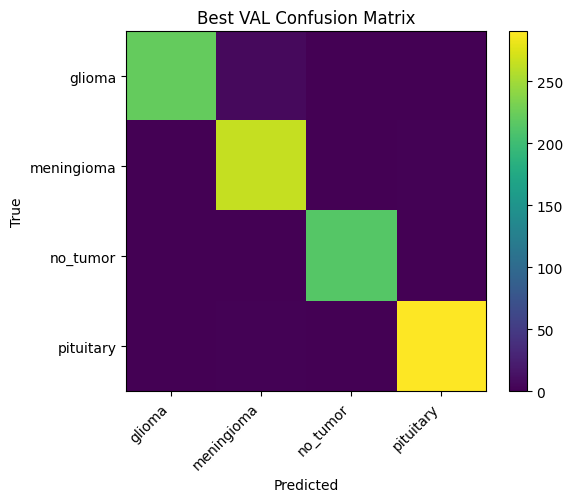

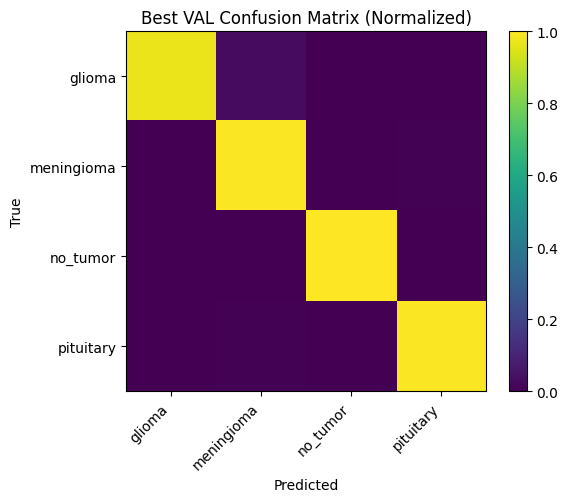

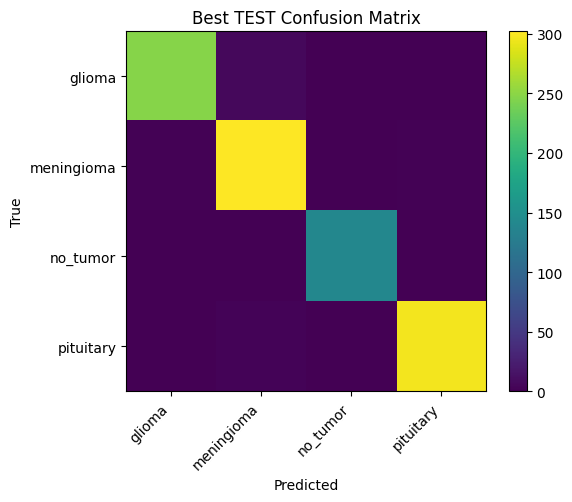

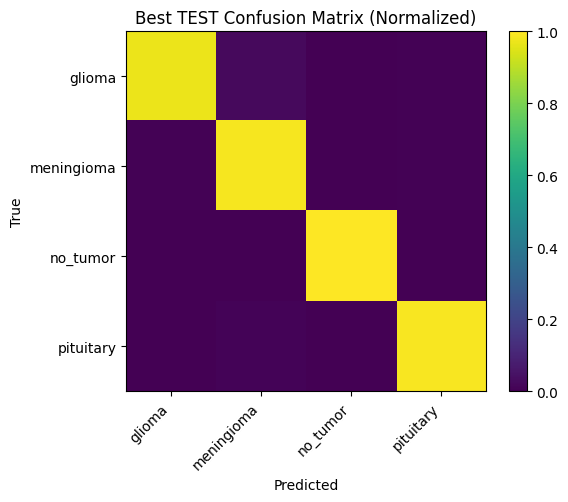


Saved best classifier checkpoint -> task5_best_classifier.pt


In [ ]:
# ============================================================
# TASK 5 — Open-Ended Design Choices (Best Accuracy)
# - Try stronger classifier architectures + flexible preprocessing
# - Pick best by VAL macro-F1
# - Report metrics + confusion matrix + ablation table
# ============================================================

from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Callable, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


# -------------------------
# 0) Preconditions / mapping
# -------------------------
if "df" not in globals():
    raise RuntimeError("`df` not found. Run the manifest loading cell first.")
if "DATA_ROOT" not in globals():
    raise RuntimeError("`DATA_ROOT` not found. Run the cell that defines DATA_ROOT.")
if "label2id" not in globals() or "class_names" not in globals():
    # rebuild if needed
    cls_rows = df[(df["task"] == "classification") & (df["is_mask"] == False)].copy()
    if len(cls_rows) == 0:
        cls_rows = df[(df["task"] == "segmentation") & (df["is_mask"] == True)].copy()
    class_names = sorted(cls_rows["tumor_label"].dropna().unique().tolist())
    label2id = {c: i for i, c in enumerate(class_names)}
    id2label = {i: c for c, i in label2id.items()}

NUM_CLASSES = len(class_names)
if NUM_CLASSES < 2:
    raise RuntimeError(f"Need >=2 classes; found {NUM_CLASSES}.")

# notebook utilities expected (from your preprocessing cell)
for need in ["fix_relpath", "PreprocessConfig", "load_image_tensor"]:
    if need not in globals():
        raise RuntimeError(f"`{need}` not found. Run the preprocessing utilities cell first.")


# -------------------------
# 1) Preprocessing choices (image_post_fn)
# -------------------------
def _clahe_gray01(img01: np.ndarray, clip: float = 2.0, grid: Tuple[int, int] = (8, 8)) -> np.ndarray:
    """
    img01: (H,W) float32 in [0,1]
    returns: (H,W) float32 in [0,1]
    """
    import cv2
    u8 = (np.clip(img01, 0, 1) * 255.0).astype(np.uint8)
    clahe = cv2.createCLAHE(clipLimit=float(clip), tileGridSize=grid)
    eq = clahe.apply(u8)
    return (eq.astype(np.float32) / 255.0)

def _zscore01(img01: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """
    img01: (H,W) float32 in [0,1]
    Returns: (H,W) float32 ~[0,1] using zscore->clip->rescale (stable for CNNs).
    """
    x = img01.astype(np.float32)
    mu = float(x.mean())
    sd = float(x.std()) if float(x.std()) > eps else eps
    z = (x - mu) / sd
    z = np.clip(z, -3.0, 3.0)
    return ((z + 3.0) / 6.0).astype(np.float32)

def make_preprocess(post_name: str) -> Callable[[np.ndarray], np.ndarray]:
    """
    Returns numpy post-processing fn to be plugged into PreprocessConfig.image_post_fn
    """
    post_name = str(post_name).lower()
    if post_name == "baseline":
        return lambda x: x.astype(np.float32)
    if post_name == "clahe":
        return lambda x: _clahe_gray01(x)
    if post_name == "clahe_zscore":
        return lambda x: _zscore01(_clahe_gray01(x))
    raise ValueError(f"Unknown preprocess: {post_name}")


# -------------------------
# 2) Augmentation (torch, simple & strong)
# -------------------------
@dataclass(frozen=True)
class AugCfg:
    hflip_p: float = 0.5
    vflip_p: float = 0.2
    rot90_p: float = 0.6
    jitter_p: float = 0.5
    contrast_rng: Tuple[float, float] = (0.9, 1.1)
    brightness_rng: Tuple[float, float] = (-0.06, 0.06)

class TensorAug:
    def __init__(self, cfg: AugCfg):
        self.cfg = cfg

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        if torch.rand(()) < self.cfg.hflip_p:
            x = torch.flip(x, dims=[-1])
        if torch.rand(()) < self.cfg.vflip_p:
            x = torch.flip(x, dims=[-2])
        if torch.rand(()) < self.cfg.rot90_p:
            k = int(torch.randint(0, 4, (1,)).item())
            x = torch.rot90(x, k, dims=[-2, -1])

        if torch.rand(()) < self.cfg.jitter_p:
            c = float(torch.empty(1).uniform_(*self.cfg.contrast_rng).item())
            b = float(torch.empty(1).uniform_(*self.cfg.brightness_rng).item())
            x = (x * c + b).clamp(0.0, 1.0)
        return x


# -------------------------
# 3) Dataset for Task5 (uses your PreprocessConfig + post_fn)
# -------------------------
class ClsTask5Dataset(Dataset):
    """
    Expects df rows with:
      relative_path
      tumor_label
    """
    def __init__(
        self,
        df_cls: pd.DataFrame,
        data_root,
        label2id: Dict[str, int],
        img_size: Tuple[int, int],
        image_post_fn: Callable[[np.ndarray], np.ndarray],
        train: bool,
        replicate_to_3ch: bool,
    ):
        self.df = df_cls.reset_index(drop=True)
        self.data_root = data_root
        self.label2id = dict(label2id)
        self.cfg = PreprocessConfig(image_size=(int(img_size[0]), int(img_size[1])), grayscale=True, image_post_fn=image_post_fn)
        self.aug = TensorAug(AugCfg()) if train else None
        self.replicate_to_3ch = bool(replicate_to_3ch)

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.iloc[idx]
        img_path = self.data_root / fix_relpath(row["relative_path"])
        x = load_image_tensor(img_path, self.cfg)  # (1,H,W) float32
        y = torch.tensor(self.label2id[str(row["tumor_label"])], dtype=torch.long)

        if self.aug is not None:
            x = self.aug(x)

        if self.replicate_to_3ch:
            x = x.repeat(3, 1, 1)  # (3,H,W)

        return x, y


# -------------------------
# 4) Models: EfficientNet-B0 (best default), ResNet18 fallback, SimpleCNN fallback
# -------------------------
def _try_build_torchvision(name: str, num_classes: int) -> Tuple[Optional[nn.Module], bool]:
    """
    Returns (model, needs_3ch).
    EfficientNet/ResNet pretrained: easiest is replicate grayscale to 3ch -> needs_3ch=True.
    """
    name = name.lower()
    try:
        import torchvision
        from torchvision import models  # noqa: F401
    except Exception:
        return None, False

    if name == "efficientnet_b0":
        try:
            from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
            m = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
            m.classifier[-1] = nn.Linear(m.classifier[-1].in_features, num_classes)
            return m, True
        except Exception:
            return None, False

    if name == "resnet18":
        try:
            from torchvision.models import resnet18, ResNet18_Weights
            m = resnet18(weights=ResNet18_Weights.DEFAULT)
            m.fc = nn.Linear(m.fc.in_features, num_classes)
            return m, True
        except Exception:
            return None, False

    return None, False

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()
        self.feat = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(inplace=True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(inplace=True), nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Linear(128, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        z = self.feat(x).flatten(1)
        return self.head(z)

def build_model(arch: str, num_classes: int) -> Tuple[nn.Module, bool]:
    m, needs_3ch = _try_build_torchvision(arch, num_classes)
    if m is not None:
        return m, needs_3ch
    if arch.lower() == "simplecnn":
        return SimpleCNN(num_classes), False
    # default fallback
    return SimpleCNN(num_classes), False


# -------------------------
# 5) Metrics + plotting
# -------------------------
@torch.no_grad()
def eval_cls(model: nn.Module, loader: DataLoader) -> Dict[str, Any]:
    model.eval()
    yt, yp = [], []
    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        logits = model(x)
        pred = torch.argmax(logits, dim=1)
        yt.extend(y.cpu().tolist())
        yp.extend(pred.cpu().tolist())

    acc = accuracy_score(yt, yp)
    p, r, f1, _ = precision_recall_fscore_support(yt, yp, average="macro", zero_division=0)
    cm = confusion_matrix(yt, yp)
    return {"acc": float(acc), "p": float(p), "r": float(r), "f1": float(f1), "cm": cm, "y_true": yt, "y_pred": yp}

def plot_cm(cm: np.ndarray, labels: List[str], normalize: bool, title: str) -> None:
    cm = cm.astype(np.float32)
    if normalize:
        rs = cm.sum(axis=1, keepdims=True)
        cm = np.divide(cm, rs, out=np.zeros_like(cm), where=rs != 0)

    plt.figure(figsize=(6, 5))
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    ticks = np.arange(len(labels))
    plt.xticks(ticks, labels, rotation=45, ha="right")
    plt.yticks(ticks, labels)
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.show()


# -------------------------
# 6) Split dataframe (robust to missing val/test)
# -------------------------
cls_df = df[(df["task"] == "classification") & (df["is_mask"] == False)].copy()
if len(cls_df) == 0:
    raise RuntimeError("No classification rows found in df (task=='classification' & is_mask==False).")

cls_train = cls_df[cls_df["split"] == "train"].copy()
cls_val = cls_df[cls_df["split"].isin(["val", "valid", "validation"])].copy()
cls_test = cls_df[cls_df["split"] == "test"].copy()

if len(cls_val) == 0 and len(cls_train) > 0:
    from sklearn.model_selection import train_test_split
    cls_train, cls_val = train_test_split(
        cls_train, test_size=0.2, random_state=42, stratify=cls_train["tumor_label"]
    )

cls_train = cls_train.reset_index(drop=True)
cls_val = cls_val.reset_index(drop=True)
cls_test = cls_test.reset_index(drop=True)

print("Split sizes:", {"train": len(cls_train), "val": len(cls_val), "test": len(cls_test)})


# -------------------------
# 7) Training loop (weighted sampler + class-weighted CE + AMP)
# -------------------------
def train_one_epoch(model: nn.Module, loader: DataLoader, optim: torch.optim.Optimizer, loss_fn: nn.Module) -> float:
    model.train()
    total, n = 0.0, 0
    scaler = torch.cuda.amp.GradScaler(enabled=torch.cuda.is_available())
    for x, y in loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)
        optim.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(enabled=torch.cuda.is_available()):
            logits = model(x)
            loss = loss_fn(logits, y)

        scaler.scale(loss).backward()
        scaler.step(optim)
        scaler.update()

        total += float(loss.item()) * x.size(0)
        n += x.size(0)
    return total / max(n, 1)


def fit_classifier(
    arch: str,
    preprocess_name: str,
    img_size: Tuple[int, int],
    epochs: int,
    batch_size: int,
    lr: float,
    weight_decay: float,
    patience: int,
) -> Tuple[Dict[str, Any], nn.Module]:
    model, needs_3ch = build_model(arch, NUM_CLASSES)
    model = model.to(DEVICE)

    post_fn = make_preprocess(preprocess_name)

    # datasets
    train_ds = ClsTask5Dataset(cls_train, DATA_ROOT, label2id, img_size, post_fn, train=True,  replicate_to_3ch=needs_3ch)
    val_ds   = ClsTask5Dataset(cls_val,   DATA_ROOT, label2id, img_size, post_fn, train=False, replicate_to_3ch=needs_3ch)
    test_ds  = ClsTask5Dataset(cls_test,  DATA_ROOT, label2id, img_size, post_fn, train=False, replicate_to_3ch=needs_3ch) if len(cls_test) else None

    # imbalance
    y_train = cls_train["tumor_label"].astype(str).map(label2id).to_numpy()
    counts = np.bincount(y_train, minlength=NUM_CLASSES).astype(np.float32)
    class_w = 1.0 / np.maximum(counts, 1.0)
    samp_w = class_w[y_train]
    sampler = WeightedRandomSampler(weights=torch.tensor(samp_w, dtype=torch.double), num_samples=len(samp_w), replacement=True)

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True) if test_ds else None

    # loss / optim
    ce_w = torch.tensor(class_w, dtype=torch.float32, device=DEVICE)
    loss_fn = nn.CrossEntropyLoss(weight=ce_w)

    optim = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=max(epochs, 1))

    best = {"f1": -1.0, "state": None, "epoch": -1}
    bad = 0

    for ep in range(1, epochs + 1):
        tr_loss = train_one_epoch(model, train_loader, optim, loss_fn)
        sched.step()

        val_m = eval_cls(model, val_loader)
        if val_m["f1"] > best["f1"]:
            best.update({"f1": val_m["f1"], "state": {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}, "epoch": ep})
            bad = 0
        else:
            bad += 1

        print(f"[{arch} | {preprocess_name}] ep {ep:02d}/{epochs}  loss={tr_loss:.4f}  val acc={val_m['acc']:.4f}  val f1={val_m['f1']:.4f}")

        if bad >= patience:
            print(f"Early stop: no val F1 improvement for {patience} epochs.")
            break

    if best["state"] is not None:
        model.load_state_dict(best["state"])

    val_final = eval_cls(model, val_loader)
    test_final = eval_cls(model, test_loader) if test_loader is not None else None

    summary = {
        "arch": arch,
        "preprocess": preprocess_name,
        "img_size": img_size,
        "val_acc": val_final["acc"],
        "val_p": val_final["p"],
        "val_r": val_final["r"],
        "val_f1": val_final["f1"],
        "val_cm": val_final["cm"],
        "test_acc": (test_final["acc"] if test_final else np.nan),
        "test_p": (test_final["p"] if test_final else np.nan),
        "test_r": (test_final["r"] if test_final else np.nan),
        "test_f1": (test_final["f1"] if test_final else np.nan),
        "test_cm": (test_final["cm"] if test_final else None),
        "best_epoch": best["epoch"],
        "needs_3ch": needs_3ch,
    }
    return summary, model


# -------------------------
# 8) Run ablation grid (small, report-friendly)
# -------------------------
EPOCHS = int(globals().get("TASK5_EPOCHS", 8))
BATCH  = int(globals().get("TASK5_BATCH", 16))
LR     = float(globals().get("TASK5_LR", 1e-4))
WD     = float(globals().get("TASK5_WD", 1e-4))
PATIENCE = int(globals().get("TASK5_PATIENCE", 3))

# For pretrained models, 224 is typical; if you want your IMG_SIZE, change it.
TASK5_IMG_SIZE = tuple(globals().get("TASK5_IMG_SIZE", (224, 224)))

# Best-first ordering
ARCHS = globals().get("TASK5_ARCHS", ["efficientnet_b0", "resnet18", "simplecnn"])
PREPROCS = globals().get("TASK5_PREPROCS", ["baseline", "clahe", "clahe_zscore"])

results: List[Dict[str, Any]] = []
best_row: Optional[Dict[str, Any]] = None
best_model: Optional[nn.Module] = None

for arch in ARCHS:
    for pp in PREPROCS:
        row, m = fit_classifier(
            arch=arch,
            preprocess_name=pp,
            img_size=TASK5_IMG_SIZE,
            epochs=EPOCHS,
            batch_size=BATCH,
            lr=LR,
            weight_decay=WD,
            patience=PATIENCE,
        )
        results.append(row)
        if best_row is None or row["val_f1"] > best_row["val_f1"]:
            best_row = row
            best_model = m

task5_df = pd.DataFrame(results).sort_values(["val_f1", "val_acc"], ascending=False).reset_index(drop=True)
display(task5_df[["arch","preprocess","img_size","val_acc","val_f1","test_acc","test_f1","best_epoch"]])

print("\nBEST CHOICE (by val macro-F1):")
print({k: best_row[k] for k in ["arch", "preprocess", "img_size", "val_acc", "val_f1", "test_acc", "test_f1", "best_epoch"]})

# Confusion matrices for best choice
labels = [str(x) for x in class_names]
plot_cm(best_row["val_cm"], labels, normalize=False, title="Best VAL Confusion Matrix")
plot_cm(best_row["val_cm"], labels, normalize=True,  title="Best VAL Confusion Matrix (Normalized)")

if best_row["test_cm"] is not None:
    plot_cm(best_row["test_cm"], labels, normalize=False, title="Best TEST Confusion Matrix")
    plot_cm(best_row["test_cm"], labels, normalize=True,  title="Best TEST Confusion Matrix (Normalized)")

# Save best model
BEST_PATH = "task5_best_classifier.pt"
torch.save(
    {
        "state_dict": best_model.state_dict() if best_model is not None else None,
        "arch": best_row["arch"],
        "preprocess": best_row["preprocess"],
        "img_size": best_row["img_size"],
        "class_names": class_names,
        "label2id": label2id,
    },
    BEST_PATH,
)
print(f"\nSaved best classifier checkpoint -> {BEST_PATH}")




In [ ]:
# ============================================================
# TASK 6 (BONUS): A, B, C  — copy-paste this whole cell
# ============================================================
# A) Separate vs Joint training comparison
# B) Different classifier heads using ResUNet++ (ResUNetPlusPlus) backbone
# C) Proposal text for novel idea (ResUNet++)



from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, List, Optional, Sequence, Tuple, Union

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix

import matplotlib.pyplot as plt


# -----------------------
# 0) Auto-detect globals
# -----------------------
DEVICE = globals().get("device", "cuda" if torch.cuda.is_available() else "cpu")
df = globals().get("df", None)
DATA_ROOT = globals().get("DATA_ROOT", None)

if df is None:
    raise RuntimeError("Need `df` (manifest dataframe) in globals.")
if DATA_ROOT is None:
    raise RuntimeError("Need `DATA_ROOT` (dataset root Path) in globals.")

SegmentationDataset = globals().get("SegmentationDataset", None)
ClassificationDataset = globals().get("ClassificationDataset", None)
MultiTaskDataset = globals().get("MultiTaskDataset", None)  # if not present, we will fallback

if SegmentationDataset is None or ClassificationDataset is None:
    raise RuntimeError("Need dataset classes: `SegmentationDataset` and `ClassificationDataset` in globals.")

IMG_SIZE = tuple(globals().get("IMG_SIZE", (256, 256)))
BATCH_SIZE = int(globals().get("BATCH_SIZE", 8))
NUM_WORKERS = int(globals().get("NUM_WORKERS", 2))
SEED = int(globals().get("SEED", 42))


def seed_everything(seed: int = 42) -> None:
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = False
    torch.backends.cudnn.benchmark = True


seed_everything(SEED)


# -----------------------
# 1) Splits + label mapping
# -----------------------
def _get_class_mapping(df_full: pd.DataFrame) -> Tuple[List[str], Dict[str, int]]:
    cls_rows = df_full[(df_full["task"] == "classification") & (df_full["is_mask"] == False)].copy()
    if len(cls_rows) == 0:
        cls_rows = df_full[(df_full["task"] == "segmentation") & (df_full["is_mask"] == True)].copy()

    if "tumor_label" not in cls_rows.columns:
        raise RuntimeError("manifest df must contain `tumor_label`.")

    class_names = sorted(cls_rows["tumor_label"].dropna().unique().tolist())
    label2id = {c: i for i, c in enumerate(class_names)}
    return class_names, label2id


def _split_segmentation(df_full: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    seg_df = df_full[(df_full["task"] == "segmentation") & (df_full["is_mask"] == True)].copy()
    seg_train = seg_df[seg_df["split"] == "train"].copy()
    seg_test = seg_df[seg_df["split"] == "test"].copy()
    seg_val = seg_df[seg_df["split"].isin(["val", "valid", "validation"])].copy()

    if len(seg_val) == 0 and len(seg_train) > 0:
        seg_train, seg_val = train_test_split(seg_train, test_size=0.2, random_state=SEED)

    return seg_train.reset_index(drop=True), seg_val.reset_index(drop=True), seg_test.reset_index(drop=True)


def _split_classification(df_full: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    cls_df = df_full[(df_full["task"] == "classification") & (df_full["is_mask"] == False)].copy()
    cls_train = cls_df[cls_df["split"] == "train"].copy()
    cls_test = cls_df[cls_df["split"] == "test"].copy()
    cls_val = cls_df[cls_df["split"].isin(["val", "valid", "validation"])].copy()

    if len(cls_val) == 0 and len(cls_train) > 0:
        strat = cls_train["tumor_label"] if "tumor_label" in cls_train.columns else None
        cls_train, cls_val = train_test_split(cls_train, test_size=0.2, random_state=SEED, stratify=strat)

    return cls_train.reset_index(drop=True), cls_val.reset_index(drop=True), cls_test.reset_index(drop=True)


def build_loaders(
    df_full: pd.DataFrame,
    data_root,
    img_size: Tuple[int, int] = (256, 256),
    batch_size: int = 8,
    num_workers: int = 2,
) -> Dict[str, Any]:
    class_names, label2id = _get_class_mapping(df_full)

    seg_train_df, seg_val_df, seg_test_df = _split_segmentation(df_full)
    cls_train_df, cls_val_df, cls_test_df = _split_classification(df_full)

    seg_train_ds = SegmentationDataset(seg_train_df, data_root, img_size=img_size)
    seg_val_ds = SegmentationDataset(seg_val_df, data_root, img_size=img_size)
    seg_test_ds = SegmentationDataset(seg_test_df, data_root, img_size=img_size)

    cls_train_ds = ClassificationDataset(cls_train_df, data_root, label2id=label2id, img_size=img_size)
    cls_val_ds = ClassificationDataset(cls_val_df, data_root, label2id=label2id, img_size=img_size)
    cls_test_ds = ClassificationDataset(cls_test_df, data_root, label2id=label2id, img_size=img_size)

    seg_train_loader = torch.utils.data.DataLoader(seg_train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    seg_val_loader = torch.utils.data.DataLoader(seg_val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    seg_test_loader = torch.utils.data.DataLoader(seg_test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    cls_train_loader = torch.utils.data.DataLoader(cls_train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
    cls_val_loader = torch.utils.data.DataLoader(cls_val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
    cls_test_loader = torch.utils.data.DataLoader(cls_test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    mt_train_loader = mt_val_loader = mt_test_loader = None
    if MultiTaskDataset is not None:
        # Build multitask from segmentation split (paired masks) and classification label2id
        mt_train_ds = MultiTaskDataset(seg_train_df, data_root, label2id=label2id, img_size=img_size)
        mt_val_ds = MultiTaskDataset(seg_val_df, data_root, label2id=label2id, img_size=img_size)
        mt_test_ds = MultiTaskDataset(seg_test_df, data_root, label2id=label2id, img_size=img_size)
        mt_train_loader = torch.utils.data.DataLoader(mt_train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers)
        mt_val_loader = torch.utils.data.DataLoader(mt_val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)
        mt_test_loader = torch.utils.data.DataLoader(mt_test_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers)

    return {
        "class_names": class_names,
        "label2id": label2id,
        "seg_train_loader": seg_train_loader,
        "seg_val_loader": seg_val_loader,
        "seg_test_loader": seg_test_loader,
        "cls_train_loader": cls_train_loader,
        "cls_val_loader": cls_val_loader,
        "cls_test_loader": cls_test_loader,
        "mt_train_loader": mt_train_loader,
        "mt_val_loader": mt_val_loader,
        "mt_test_loader": mt_test_loader,
    }


loaders = build_loaders(df, DATA_ROOT, img_size=IMG_SIZE, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS)
CLASS_NAMES = loaders["class_names"]
NUM_CLASSES = len(CLASS_NAMES)
print("Device:", DEVICE)
print("Classes:", CLASS_NAMES)


# -----------------------
# 2) Task 4 metrics (minimal, used by bonus)
# -----------------------
def _extract_outputs(model_out: Any) -> Tuple[Optional[torch.Tensor], Optional[torch.Tensor]]:
    seg, cls = None, None
    if isinstance(model_out, (tuple, list)) and len(model_out) >= 2:
        a, b = model_out[0], model_out[1]
        if isinstance(a, torch.Tensor) and a.dim() >= 3:
            seg, cls = a, b if isinstance(b, torch.Tensor) else None
        elif isinstance(b, torch.Tensor) and b.dim() >= 3:
            seg, cls = b, a if isinstance(a, torch.Tensor) else None
        else:
            seg = a if isinstance(a, torch.Tensor) else None
            cls = b if isinstance(b, torch.Tensor) else None
    elif isinstance(model_out, dict):
        for k in ("seg", "mask", "seg_logits", "segmentation", "logits_seg"):
            if k in model_out and isinstance(model_out[k], torch.Tensor):
                seg = model_out[k]
                break
        for k in ("cls", "class", "cls_logits", "classification", "logits_cls"):
            if k in model_out and isinstance(model_out[k], torch.Tensor):
                cls = model_out[k]
                break
    elif isinstance(model_out, torch.Tensor):
        if model_out.dim() >= 3:
            seg = model_out
        elif model_out.dim() == 2:
            cls = model_out
    return seg, cls


def _ensure_n1hw(x: torch.Tensor) -> torch.Tensor:
    if x.dim() == 3:
        return x.unsqueeze(1)
    if x.dim() == 4:
        return x
    raise ValueError(f"Expected 3D/4D tensor, got {tuple(x.shape)}")


def _to_prob_if_logits(x: torch.Tensor) -> torch.Tensor:
    if not x.dtype.is_floating_point:
        return x.float()
    if x.min() < 0.0 or x.max() > 1.0:
        return torch.sigmoid(x)
    return x


def _binarize(x: torch.Tensor, threshold: float = 0.5) -> torch.Tensor:
    x = _ensure_n1hw(x)
    x = _to_prob_if_logits(x)
    return (x >= threshold).float()


def dice_coefficient(pred: torch.Tensor, targ: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    p = _binarize(pred, 0.5).flatten(1)
    t = _binarize(targ, 0.5).flatten(1)
    inter = (p * t).sum(dim=1)
    denom = p.sum(dim=1) + t.sum(dim=1)
    return (2 * inter + eps) / (denom + eps)


def iou_score(pred: torch.Tensor, targ: torch.Tensor, eps: float = 1e-7) -> torch.Tensor:
    p = _binarize(pred, 0.5).flatten(1)
    t = _binarize(targ, 0.5).flatten(1)
    inter = (p * t).sum(dim=1)
    union = p.sum(dim=1) + t.sum(dim=1) - inter
    return (inter + eps) / (union + eps)


def pixel_accuracy(pred: torch.Tensor, targ: torch.Tensor) -> torch.Tensor:
    p = _binarize(pred, 0.5)
    t = _binarize(targ, 0.5)
    return (p == t).float().flatten(1).mean(dim=1)


@torch.no_grad()
def evaluate_segmentation(model: nn.Module, loader, device: str = DEVICE, threshold: float = 0.5) -> Dict[str, float]:
    model.eval()
    device_t = torch.device(device)
    dice_vals, iou_vals, pix_vals = [], [], []
    for batch in loader:
        x, m = batch[0].to(device_t), batch[1].to(device_t)
        out = model(x)
        seg, _ = _extract_outputs(out)
        if seg is None:
            raise ValueError("No segmentation output found.")
        pred_bin = _binarize(seg, threshold)
        targ_bin = _binarize(m, 0.5)
        dice_vals.extend(dice_coefficient(pred_bin, targ_bin).cpu().tolist())
        iou_vals.extend(iou_score(pred_bin, targ_bin).cpu().tolist())
        pix_vals.extend(pixel_accuracy(pred_bin, targ_bin).cpu().tolist())
    return {"mIoU": float(np.mean(iou_vals)), "Dice": float(np.mean(dice_vals)), "PixelAcc": float(np.mean(pix_vals))}


@torch.no_grad()
def evaluate_classification(model: nn.Module, loader, device: str = DEVICE, class_names: Optional[Sequence[str]] = None) -> Dict[str, Any]:
    model.eval()
    device_t = torch.device(device)
    y_true, y_pred = [], []
    for batch in loader:
        x = batch[0].to(device_t)
        y = batch[-1].to(device_t)
        out = model(x)
        _, cls = _extract_outputs(out)
        if cls is None:
            if isinstance(out, torch.Tensor) and out.dim() == 2:
                cls = out
            else:
                raise ValueError("No classification output found.")
        pred = torch.argmax(cls, dim=1)
        y_true.extend(y.detach().cpu().tolist())
        y_pred.extend(pred.detach().cpu().tolist())

    cm = confusion_matrix(y_true, y_pred)
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    p_w, r_w, f_w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

    if class_names is None:
        class_names = [str(i) for i in range(cm.shape[0])]

    return {
        "Accuracy": float(acc),
        "Precision_macro": float(p_macro),
        "Recall_macro": float(r_macro),
        "F1_macro": float(f_macro),
        "Precision_weighted": float(p_w),
        "Recall_weighted": float(r_w),
        "F1_weighted": float(f_w),
        "ConfusionMatrix": cm,
        "ClassNames": list(class_names),
    }


def plot_confusion_matrix(cm: np.ndarray, class_names: Sequence[str], normalize: bool = False, title: str = "Confusion Matrix") -> None:
    cm_plot = cm.astype(np.float64)
    if normalize:
        row = cm_plot.sum(axis=1, keepdims=True)
        cm_plot = np.divide(cm_plot, np.maximum(row, 1e-12))

    plt.figure(figsize=(7, 6))
    plt.imshow(cm_plot, interpolation="nearest")
    plt.title(title)
    plt.colorbar()

    ticks = np.arange(len(class_names))
    plt.xticks(ticks, class_names, rotation=45, ha="right")
    plt.yticks(ticks, class_names)

    thresh = cm_plot.max() * 0.6 if cm_plot.size else 0.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val = cm_plot[i, j]
            txt = f"{val:.2f}" if normalize else f"{int(cm[i, j])}"
            plt.text(j, i, txt, ha="center", va="center", color="white" if val > thresh else "black")

    plt.ylabel("True")
    plt.xlabel("Pred")
    plt.tight_layout()
    plt.show()


# -----------------------
# 3) Losses + train loops
# -----------------------
class DiceLoss(nn.Module):
    def __init__(self, eps: float = 1e-7) -> None:
        super().__init__()
        self.eps = eps

    def forward(self, logits: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        probs = torch.sigmoid(_ensure_n1hw(logits))
        target = _ensure_n1hw(target).float()
        p = probs.flatten(1)
        t = target.flatten(1)
        inter = (p * t).sum(dim=1)
        denom = p.sum(dim=1) + t.sum(dim=1)
        dice = (2.0 * inter + self.eps) / (denom + self.eps)
        return 1.0 - dice.mean()


def segmentation_loss(seg_logits: torch.Tensor, mask: torch.Tensor) -> torch.Tensor:
    bce = F.binary_cross_entropy_with_logits(_ensure_n1hw(seg_logits), _ensure_n1hw(mask).float())
    dice = DiceLoss()(_ensure_n1hw(seg_logits), _ensure_n1hw(mask))
    return 0.5 * bce + 0.5 * dice


def classification_loss(cls_logits: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return F.cross_entropy(cls_logits, y.long())


@torch.no_grad()
def _infer_in_channels(loader) -> int:
    batch = next(iter(loader))
    x = batch[0]
    return int(x.shape[1])


def train_one_epoch_seg(model: nn.Module, loader, optim: torch.optim.Optimizer, device: str = DEVICE) -> float:
    model.train()
    device_t = torch.device(device)
    losses = []
    for batch in loader:
        x, m = batch[0].to(device_t), batch[1].to(device_t)
        out = model(x)
        seg, _ = _extract_outputs(out)
        if seg is None:
            seg = out if isinstance(out, torch.Tensor) else None
        if seg is None:
            raise ValueError("No segmentation output for training.")
        loss = segmentation_loss(seg, m)

        optim.zero_grad(set_to_none=True)
        loss.backward()
        optim.step()
        losses.append(float(loss.detach().cpu()))
    return float(np.mean(losses)) if losses else 0.0


def train_one_epoch_cls(model: nn.Module, loader, optim: torch.optim.Optimizer, device: str = DEVICE) -> float:
    model.train()
    device_t = torch.device(device)
    losses = []
    for batch in loader:
        x = batch[0].to(device_t)
        y = batch[-1].to(device_t)
        out = model(x)
        _, cls = _extract_outputs(out)
        if cls is None:
            cls = out if isinstance(out, torch.Tensor) else None
        if cls is None:
            raise ValueError("No classification output for training.")
        loss = classification_loss(cls, y)

        optim.zero_grad(set_to_none=True)
        loss.backward()
        optim.step()
        losses.append(float(loss.detach().cpu()))
    return float(np.mean(losses)) if losses else 0.0


def train_one_epoch_joint(
    model: nn.Module,
    loader,
    optim: torch.optim.Optimizer,
    device: str = DEVICE,
    alpha_cls: float = 1.0,
) -> float:
    model.train()
    device_t = torch.device(device)
    losses = []
    for batch in loader:
        if len(batch) < 3:
            raise RuntimeError("Joint training requires MultiTaskDataset yielding (x, mask, y).")
        x, m, y = batch[0].to(device_t), batch[1].to(device_t), batch[2].to(device_t)

        out = model(x)
        seg, cls = _extract_outputs(out)
        if seg is None or cls is None:
            raise ValueError("Joint model must output both (seg_logits, cls_logits).")

        loss = segmentation_loss(seg, m) + alpha_cls * classification_loss(cls, y)

        optim.zero_grad(set_to_none=True)
        loss.backward()
        optim.step()
        losses.append(float(loss.detach().cpu()))
    return float(np.mean(losses)) if losses else 0.0


# -----------------------
# 4) ResUNet++ (ResUNetPlusPlus) with classifier head
# -----------------------
class SqueezeExcite(nn.Module):
    def __init__(self, channels: int, reduction: int = 8) -> None:
        super().__init__()
        hidden = max(4, channels // reduction)
        self.fc1 = nn.Conv2d(channels, hidden, kernel_size=1)
        self.fc2 = nn.Conv2d(hidden, channels, kernel_size=1)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        s = F.adaptive_avg_pool2d(x, 1)
        s = F.relu(self.fc1(s), inplace=True)
        s = torch.sigmoid(self.fc2(s))
        return x * s


class ResidualConv(nn.Module):
    def __init__(self, in_ch: int, out_ch: int) -> None:
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)
        self.se = SqueezeExcite(out_ch)
        self.skip = None
        if in_ch != out_ch:
            self.skip = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, bias=False),
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        identity = x if self.skip is None else self.skip(x)
        x = F.relu(self.bn1(self.conv1(x)), inplace=True)
        x = self.bn2(self.conv2(x))
        x = self.se(x)
        x = F.relu(x + identity, inplace=True)
        return x


class ASPP(nn.Module):
    def __init__(self, in_ch: int, out_ch: int, rates: Sequence[int] = (1, 6, 12, 18)) -> None:
        super().__init__()
        self.branches = nn.ModuleList()
        for r in rates:
            k = 1 if r == 1 else 3
            p = 0 if r == 1 else r
            self.branches.append(
                nn.Sequential(
                    nn.Conv2d(in_ch, out_ch, kernel_size=k, padding=p, dilation=r, bias=False),
                    nn.BatchNorm2d(out_ch),
                    nn.ReLU(inplace=True),
                )
            )
        self.image_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
        self.project = nn.Sequential(
            nn.Conv2d(out_ch * (len(rates) + 1), out_ch, kernel_size=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feats = [b(x) for b in self.branches]
        ip = self.image_pool(x)
        ip = F.interpolate(ip, size=x.shape[-2:], mode="bilinear", align_corners=False)
        feats.append(ip)
        x = torch.cat(feats, dim=1)
        return self.project(x)


class AttentionGate(nn.Module):
    def __init__(self, g_ch: int, x_ch: int, inter_ch: int) -> None:
        super().__init__()
        self.Wg = nn.Sequential(nn.Conv2d(g_ch, inter_ch, 1, bias=False), nn.BatchNorm2d(inter_ch))
        self.Wx = nn.Sequential(nn.Conv2d(x_ch, inter_ch, 1, bias=False), nn.BatchNorm2d(inter_ch))
        self.psi = nn.Sequential(nn.Conv2d(inter_ch, 1, 1, bias=True), nn.BatchNorm2d(1), nn.Sigmoid())

    def forward(self, g: torch.Tensor, x: torch.Tensor) -> torch.Tensor:
        # g: decoder signal (upsampled), x: skip feature
        a = F.relu(self.Wg(g) + self.Wx(x), inplace=True)
        w = self.psi(a)
        return x * w


def build_classifier_head(head: str, in_features: int, num_classes: int) -> nn.Module:
    head = head.lower()
    if head == "linear":
        return nn.Linear(in_features, num_classes)
    if head == "mlp":
        hidden = max(64, in_features // 2)
        return nn.Sequential(nn.Linear(in_features, hidden), nn.ReLU(inplace=True), nn.Dropout(0.2), nn.Linear(hidden, num_classes))
    if head == "mlp_big":
        hidden = max(128, in_features)
        return nn.Sequential(
            nn.Linear(in_features, hidden), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(hidden, hidden), nn.ReLU(inplace=True), nn.Dropout(0.3),
            nn.Linear(hidden, num_classes),
        )
    raise ValueError("head must be one of: linear | mlp | mlp_big")


class ResUNetPlusPlusWithClassifier(nn.Module):
    """
    Practical ResUNet++-style model:
      - Residual + SE blocks
      - ASPP bottleneck
      - Attention gates on skip connections
      - Classifier head from bottleneck (GAP -> head)
    Outputs: (seg_logits, cls_logits)
    """
    def __init__(self, in_ch: int, num_classes: int, base: int = 32, cls_head: str = "mlp") -> None:
        super().__init__()
        self.enc1 = ResidualConv(in_ch, base)
        self.pool1 = nn.MaxPool2d(2)
        self.enc2 = ResidualConv(base, base * 2)
        self.pool2 = nn.MaxPool2d(2)
        self.enc3 = ResidualConv(base * 2, base * 4)
        self.pool3 = nn.MaxPool2d(2)
        self.enc4 = ResidualConv(base * 4, base * 8)
        self.pool4 = nn.MaxPool2d(2)

        self.bottleneck = nn.Sequential(
            ResidualConv(base * 8, base * 16),
            ASPP(base * 16, base * 16),
        )

        # decoder
        self.up4 = nn.ConvTranspose2d(base * 16, base * 8, kernel_size=2, stride=2)
        self.att4 = AttentionGate(g_ch=base * 8, x_ch=base * 8, inter_ch=base * 4)
        self.dec4 = ResidualConv(base * 16, base * 8)

        self.up3 = nn.ConvTranspose2d(base * 8, base * 4, kernel_size=2, stride=2)
        self.att3 = AttentionGate(g_ch=base * 4, x_ch=base * 4, inter_ch=base * 2)
        self.dec3 = ResidualConv(base * 8, base * 4)

        self.up2 = nn.ConvTranspose2d(base * 4, base * 2, kernel_size=2, stride=2)
        self.att2 = AttentionGate(g_ch=base * 2, x_ch=base * 2, inter_ch=base)
        self.dec2 = ResidualConv(base * 4, base * 2)

        self.up1 = nn.ConvTranspose2d(base * 2, base, kernel_size=2, stride=2)
        self.att1 = AttentionGate(g_ch=base, x_ch=base, inter_ch=max(8, base // 2))
        self.dec1 = ResidualConv(base * 2, base)

        self.seg_head = nn.Conv2d(base, 1, kernel_size=1)

        # classifier from bottleneck
        self.cls_pool = nn.AdaptiveAvgPool2d(1)
        self.cls_head = build_classifier_head(cls_head, in_features=base * 16, num_classes=num_classes)

    def forward(self, x: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))
        b = self.bottleneck(self.pool4(e4))

        # classification
        z = self.cls_pool(b).flatten(1)
        cls_logits = self.cls_head(z)

        # decode + attention skips
        d4 = self.up4(b)
        s4 = self.att4(d4, e4)
        d4 = self.dec4(torch.cat([d4, s4], dim=1))

        d3 = self.up3(d4)
        s3 = self.att3(d3, e3)
        d3 = self.dec3(torch.cat([d3, s3], dim=1))

        d2 = self.up2(d3)
        s2 = self.att2(d2, e2)
        d2 = self.dec2(torch.cat([d2, s2], dim=1))

        d1 = self.up1(d2)
        s1 = self.att1(d1, e1)
        d1 = self.dec1(torch.cat([d1, s1], dim=1))

        seg_logits = self.seg_head(d1)
        return seg_logits, cls_logits


# -----------------------
# 5) BONUS A: Separate vs Joint training comparison
# -----------------------
@dataclass(frozen=True)
class BonusAConfig:
    epochs: int = 3
    lr: float = 1e-3
    weight_decay: float = 1e-4
    alpha_cls: float = 1.0
    base_channels: int = 32
    cls_head: str = "mlp"  # used in joint model


def run_bonus_A_separate_vs_joint(
    cfg: BonusAConfig,
    loaders_dict: Dict[str, Any],
    threshold: float = 0.5,
) -> pd.DataFrame:
    """
    Separate:
      - Train segmentation (seg logits only) using ResUNet++ seg output
      - Train classification (cls logits only) using same backbone but ignore seg loss
    Joint:
      - Train both heads together on MultiTaskDataset (if available)

    Returns a summary dataframe for VAL and TEST.
    """
    seg_train_loader = loaders_dict["seg_train_loader"]
    seg_val_loader = loaders_dict["seg_val_loader"]
    seg_test_loader = loaders_dict["seg_test_loader"]

    cls_train_loader = loaders_dict["cls_train_loader"]
    cls_val_loader = loaders_dict["cls_val_loader"]
    cls_test_loader = loaders_dict["cls_test_loader"]

    mt_train_loader = loaders_dict.get("mt_train_loader", None)
    mt_val_loader = loaders_dict.get("mt_val_loader", None)
    mt_test_loader = loaders_dict.get("mt_test_loader", None)

    in_ch = _infer_in_channels(seg_train_loader)

    # -------- Separate training: segmentation-only --------
    seg_model = ResUNetPlusPlusWithClassifier(in_ch=in_ch, num_classes=NUM_CLASSES, base=cfg.base_channels, cls_head=cfg.cls_head).to(DEVICE)
    opt_seg = torch.optim.AdamW(seg_model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    for ep in range(cfg.epochs):
        loss_tr = train_one_epoch_seg(seg_model, seg_train_loader, opt_seg, device=DEVICE)
        seg_val = evaluate_segmentation(seg_model, seg_val_loader, device=DEVICE, threshold=threshold)
        print(f"[A-SEPARATE][Seg][Ep {ep+1}/{cfg.epochs}] loss={loss_tr:.4f} valDice={seg_val['Dice']:.4f} valmIoU={seg_val['mIoU']:.4f}")

    seg_val_m = evaluate_segmentation(seg_model, seg_val_loader, device=DEVICE, threshold=threshold)
    seg_test_m = evaluate_segmentation(seg_model, seg_test_loader, device=DEVICE, threshold=threshold)

    # -------- Separate training: classification-only --------
    cls_model = ResUNetPlusPlusWithClassifier(in_ch=in_ch, num_classes=NUM_CLASSES, base=cfg.base_channels, cls_head=cfg.cls_head).to(DEVICE)
    opt_cls = torch.optim.AdamW(cls_model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

    for ep in range(cfg.epochs):
        loss_tr = train_one_epoch_cls(cls_model, cls_train_loader, opt_cls, device=DEVICE)
        cls_val = evaluate_classification(cls_model, cls_val_loader, device=DEVICE, class_names=CLASS_NAMES)
        print(f"[A-SEPARATE][Cls][Ep {ep+1}/{cfg.epochs}] loss={loss_tr:.4f} valF1m={cls_val['F1_macro']:.4f} valAcc={cls_val['Accuracy']:.4f}")

    cls_val_m = evaluate_classification(cls_model, cls_val_loader, device=DEVICE, class_names=CLASS_NAMES)
    cls_test_m = evaluate_classification(cls_model, cls_test_loader, device=DEVICE, class_names=CLASS_NAMES)

    rows: List[Dict[str, Any]] = []
    rows.append({
        "mode": "separate",
        "split": "val",
        "seg_mIoU": seg_val_m["mIoU"],
        "seg_Dice": seg_val_m["Dice"],
        "seg_PixelAcc": seg_val_m["PixelAcc"],
        "cls_Acc": cls_val_m["Accuracy"],
        "cls_F1_macro": cls_val_m["F1_macro"],
    })
    rows.append({
        "mode": "separate",
        "split": "test",
        "seg_mIoU": seg_test_m["mIoU"],
        "seg_Dice": seg_test_m["Dice"],
        "seg_PixelAcc": seg_test_m["PixelAcc"],
        "cls_Acc": cls_test_m["Accuracy"],
        "cls_F1_macro": cls_test_m["F1_macro"],
    })

    # -------- Joint training (if MultiTask available) --------
    if mt_train_loader is not None and mt_val_loader is not None and mt_test_loader is not None:
        joint_model = ResUNetPlusPlusWithClassifier(in_ch=in_ch, num_classes=NUM_CLASSES, base=cfg.base_channels, cls_head=cfg.cls_head).to(DEVICE)
        opt_joint = torch.optim.AdamW(joint_model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

        for ep in range(cfg.epochs):
            loss_tr = train_one_epoch_joint(joint_model, mt_train_loader, opt_joint, device=DEVICE, alpha_cls=cfg.alpha_cls)
            seg_val = evaluate_segmentation(joint_model, mt_val_loader, device=DEVICE, threshold=threshold)
            cls_val = evaluate_classification(joint_model, mt_val_loader, device=DEVICE, class_names=CLASS_NAMES)
            print(
                f"[A-JOINT][Ep {ep+1}/{cfg.epochs}] loss={loss_tr:.4f} "
                f"valDice={seg_val['Dice']:.4f} valF1m={cls_val['F1_macro']:.4f}"
            )

        seg_val_j = evaluate_segmentation(joint_model, mt_val_loader, device=DEVICE, threshold=threshold)
        seg_test_j = evaluate_segmentation(joint_model, mt_test_loader, device=DEVICE, threshold=threshold)
        cls_val_j = evaluate_classification(joint_model, mt_val_loader, device=DEVICE, class_names=CLASS_NAMES)
        cls_test_j = evaluate_classification(joint_model, mt_test_loader, device=DEVICE, class_names=CLASS_NAMES)

        rows.append({
            "mode": "joint",
            "split": "val",
            "seg_mIoU": seg_val_j["mIoU"],
            "seg_Dice": seg_val_j["Dice"],
            "seg_PixelAcc": seg_val_j["PixelAcc"],
            "cls_Acc": cls_val_j["Accuracy"],
            "cls_F1_macro": cls_val_j["F1_macro"],
        })
        rows.append({
            "mode": "joint",
            "split": "test",
            "seg_mIoU": seg_test_j["mIoU"],
            "seg_Dice": seg_test_j["Dice"],
            "seg_PixelAcc": seg_test_j["PixelAcc"],
            "cls_Acc": cls_test_j["Accuracy"],
            "cls_F1_macro": cls_test_j["F1_macro"],
        })
    else:
        print("MultiTaskDataset not found; JOINT training comparison skipped (A).")

    out = pd.DataFrame(rows)
    out = out.sort_values(by=["split", "mode"]).reset_index(drop=True)
    return out


# -----------------------
# 6) BONUS B: Try different classifier heads (ResUNet++)
# -----------------------
@dataclass(frozen=True)
class BonusBConfig:
    epochs: int = 3
    lr: float = 1e-3
    weight_decay: float = 1e-4
    alpha_cls: float = 1.0
    base_channels: int = 32
    heads: Tuple[str, ...] = ("linear", "mlp", "mlp_big")


def run_bonus_B_classifier_heads(
    cfg: BonusBConfig,
    loaders_dict: Dict[str, Any],
    threshold: float = 0.5,
) -> pd.DataFrame:
    """
    Trains JOINT (preferred) with ResUNet++ using different classifier heads and compares results.
    If MultiTaskDataset isn't available, it falls back to classification-only training and reports cls metrics only.
    """
    in_ch = _infer_in_channels(loaders_dict["seg_train_loader"])

    mt_train = loaders_dict.get("mt_train_loader", None)
    mt_val = loaders_dict.get("mt_val_loader", None)
    mt_test = loaders_dict.get("mt_test_loader", None)

    cls_train = loaders_dict["cls_train_loader"]
    cls_val = loaders_dict["cls_val_loader"]
    cls_test = loaders_dict["cls_test_loader"]

    rows: List[Dict[str, Any]] = []

    for head in cfg.heads:
        model = ResUNetPlusPlusWithClassifier(in_ch=in_ch, num_classes=NUM_CLASSES, base=cfg.base_channels, cls_head=head).to(DEVICE)
        opt = torch.optim.AdamW(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)

        if mt_train is not None:
            for ep in range(cfg.epochs):
                loss_tr = train_one_epoch_joint(model, mt_train, opt, device=DEVICE, alpha_cls=cfg.alpha_cls)
                seg_val = evaluate_segmentation(model, mt_val, device=DEVICE, threshold=threshold)
                cls_val_m = evaluate_classification(model, mt_val, device=DEVICE, class_names=CLASS_NAMES)
                print(
                    f"[B][Head={head}][Ep {ep+1}/{cfg.epochs}] loss={loss_tr:.4f} "
                    f"valDice={seg_val['Dice']:.4f} valF1m={cls_val_m['F1_macro']:.4f}"
                )

            seg_val_m = evaluate_segmentation(model, mt_val, device=DEVICE, threshold=threshold)
            seg_test_m = evaluate_segmentation(model, mt_test, device=DEVICE, threshold=threshold)
            cls_val_m = evaluate_classification(model, mt_val, device=DEVICE, class_names=CLASS_NAMES)
            cls_test_m = evaluate_classification(model, mt_test, device=DEVICE, class_names=CLASS_NAMES)

            rows.append({
                "backbone": "ResUNet++",
                "cls_head": head,
                "split": "val",
                "seg_Dice": seg_val_m["Dice"],
                "seg_mIoU": seg_val_m["mIoU"],
                "cls_Acc": cls_val_m["Accuracy"],
                "cls_F1_macro": cls_val_m["F1_macro"],
            })
            rows.append({
                "backbone": "ResUNet++",
                "cls_head": head,
                "split": "test",
                "seg_Dice": seg_test_m["Dice"],
                "seg_mIoU": seg_test_m["mIoU"],
                "cls_Acc": cls_test_m["Accuracy"],
                "cls_F1_macro": cls_test_m["F1_macro"],
            })
        else:
            print(f"[B] MultiTaskDataset not found. Running classification-only for head={head}.")
            for ep in range(cfg.epochs):
                loss_tr = train_one_epoch_cls(model, cls_train, opt, device=DEVICE)
                cls_val_m = evaluate_classification(model, cls_val, device=DEVICE, class_names=CLASS_NAMES)
                print(f"[B][Head={head}][Ep {ep+1}/{cfg.epochs}] loss={loss_tr:.4f} valF1m={cls_val_m['F1_macro']:.4f}")

            cls_val_m = evaluate_classification(model, cls_val, device=DEVICE, class_names=CLASS_NAMES)
            cls_test_m = evaluate_classification(model, cls_test, device=DEVICE, class_names=CLASS_NAMES)
            rows.append({
                "backbone": "ResUNet++",
                "cls_head": head,
                "split": "val",
                "cls_Acc": cls_val_m["Accuracy"],
                "cls_F1_macro": cls_val_m["F1_macro"],
            })
            rows.append({
                "backbone": "ResUNet++",
                "cls_head": head,
                "split": "test",
                "cls_Acc": cls_test_m["Accuracy"],
                "cls_F1_macro": cls_test_m["F1_macro"],
            })

    out = pd.DataFrame(rows).sort_values(by=["split", "cls_F1_macro"], ascending=[True, False]).reset_index(drop=True)
    return out


# -----------------------
# 7) BONUS C: Proposal (ResUNet++)
# -----------------------
BONUS_IDEA_PROPOSAL_RESUNETPP = f"""
BONUS IDEA (C): Use ResUNet++ as an upgraded backbone for segmentation + classification.

What:
- Replace baseline U-Net / Attention U-Net with ResUNet++-style network:
  - Residual + Squeeze-and-Excitation blocks (better feature reuse)
  - ASPP at bottleneck (better multi-scale context)
  - Attention gates on skip connections (better focus on lesion regions)

Why it helps:
- Lesion boundaries are small/irregular ⇒ multi-scale + attention helps segmentation.
- Encoder bottleneck features become stronger ⇒ better classification head accuracy.

How to evaluate:
- Compare against baseline U-Net and Attention U-Net using Task 4 metrics:
  - Segmentation: Dice, mIoU, PixelAcc
  - Classification: Accuracy, macro-F1, confusion matrix
- Report both separate vs joint training (Bonus A) and classifier heads (Bonus B).

Deliverable:
- A table of results (val/test) + plots of confusion matrices, plus a short analysis section.
Classes: {CLASS_NAMES}
"""

print(BONUS_IDEA_PROPOSAL_RESUNETPP)


# ============================================================
# RUN BONUS TASKS (edit epochs if needed)
# ============================================================
# BONUS A
bonusA_cfg = BonusAConfig(epochs=3, lr=1e-3, weight_decay=1e-4, alpha_cls=1.0, base_channels=32, cls_head="mlp")
bonusA_table = run_bonus_A_separate_vs_joint(bonusA_cfg, loaders, threshold=0.5)
print("\nBONUS A RESULTS:\n", bonusA_table)
# bonusA_table.to_csv("bonusA_separate_vs_joint.csv", index=False)

# BONUS B
bonusB_cfg = BonusBConfig(epochs=3, lr=1e-3, weight_decay=1e-4, alpha_cls=1.0, base_channels=32, heads=("linear", "mlp", "mlp_big"))
bonusB_table = run_bonus_B_classifier_heads(bonusB_cfg, loaders, threshold=0.5)
print("\nBONUS B RESULTS:\n", bonusB_table)
# bonusB_table.to_csv("bonusB_classifier_heads_resunetpp.csv", index=False)

# Optional: show confusion matrix for best head (VAL)
if not bonusB_table.empty and "split" in bonusB_table.columns and "cls_head" in bonusB_table.columns:
    best_val_row = bonusB_table[bonusB_table["split"] == "val"].sort_values("cls_F1_macro", ascending=False).head(1)
    if len(best_val_row) == 1 and loaders.get("mt_val_loader", None) is not None:
        best_head = best_val_row.iloc[0]["cls_head"]
        in_ch = _infer_in_channels(loaders["seg_train_loader"])
        best_model = ResUNetPlusPlusWithClassifier(in_ch=in_ch, num_classes=NUM_CLASSES, base=32, cls_head=best_head).to(DEVICE)
        # Note: best_model here is untrained (fresh). For a real CM, train or reuse the trained model instance.
        print(f"\nNote: To plot confusion matrix for the *trained* best model, plot inside the training loop or keep the trained model.")





TypeError: ClassificationDataset.__init__() got an unexpected keyword argument 'label2id'

Device: cuda
Classes: ['glioma', 'meningioma', 'no_tumor', 'pituitary']
⚠️ No val split found; created 2 0% val split from train.
Train masks: 3147 | Val masks: 786
Epoch 01/10 | train=0.9708 | val=1.0926 | dice=0.0993 | acc=0.5846
✅ Saved best -> unet_multitask_best.pt (val_loss=1.0926)
Epoch 02/10 | train=0.7124 | val=2.3313 | dice=0.2691 | acc=0.4179
Epoch 03/10 | train=0.6207 | val=0.7883 | dice=0.2838 | acc=0.7323
✅ Saved best -> unet_multitask_best.pt (val_loss=0.7883)
Epoch 04/10 | train=0.5518 | val=0.5115 | dice=0.3821 | acc=0.8245
✅ Saved best -> unet_multitask_best.pt (val_loss=0.5115)
Epoch 05/10 | train=0.5005 | val=1.1801 | dice=0.1961 | acc=0.5783
Epoch 06/10 | train=0.4743 | val=0.4048 | dice=0.4817 | acc=0.8687
✅ Saved best -> unet_multitask_best.pt (val_loss=0.4048)
Epoch 07/10 | train=0.4523 | val=0.4903 | dice=0.4248 | acc=0.8346
Epoch 08/10 | train=0.4046 | val=1.2871 | dice=0.5127 | acc=0.4962
Epoch 09/10 | train=0.4014 | val=0.4541 | dice=0.5432 | acc=0.8460
Epoc

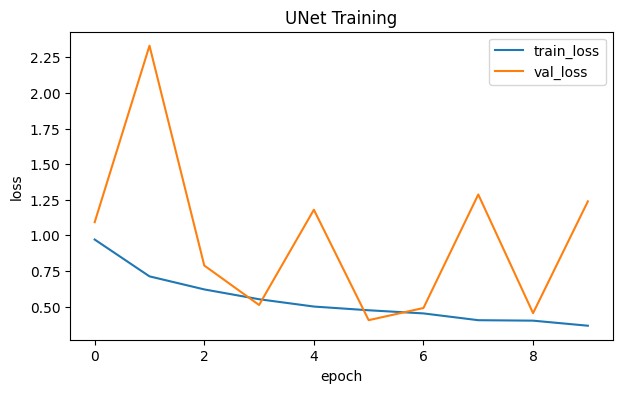

DONE. Best checkpoint at: /content/unet_multitask_best.pt


In [ ]:
# ============================================================
# ✅ RETRAIN UNet (with optional CLASSIFIER head) + SAVE a proper ckpt
# This creates a checkpoint that your UNet demo cell can load later.
#
# Assumes BRISC/manifest style:
#   DATA_ROOT/manifest.csv with columns like:
#   task, is_mask, split, relative_path, linked_image, tumor_label
#
# Output:
#   /content/unet_multitask_best.pt   (or current working dir)
# ============================================================

import os, random
from pathlib import Path
import numpy as np
import pandas as pd
import cv2
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

# -------------------- EDIT THESE --------------------
DATA_ROOT = Path("/content/brisc2025/brisc2025")  # change if needed
MANIFEST  = DATA_ROOT / "manifest.csv"

IMG_SIZE  = (256, 256)
BATCH     = 8
EPOCHS    = 10
LR        = 1e-3

BASE_CH   = 32
USE_CLASSIFIER_HEAD = True       # ✅ keep True if you need UNet to do classification demo
CLS_WEIGHT = 1.0                 # weight for classification loss

SAVE_PATH = Path("unet_multitask_best.pt")
# ---------------------------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

# ---------- utils ----------
def fix_relpath(p: str) -> str:
    p = str(p).replace("\\", "/")
    p = p.lstrip("./")
    return p

def read_gray01_resize(path: Path, img_size):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise RuntimeError(f"Could not read image: {path}")
    img = cv2.resize(img, (int(img_size[1]), int(img_size[0])), interpolation=cv2.INTER_AREA)
    return (img.astype(np.float32) / 255.0)

def read_mask01_resize(path: Path, img_size):
    m = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if m is None:
        raise RuntimeError(f"Could not read mask: {path}")
    m = cv2.resize(m, (int(img_size[1]), int(img_size[0])), interpolation=cv2.INTER_NEAREST)
    m01 = (m.astype(np.float32) / 255.0)
    return m01

# ---------- load manifest ----------
if not MANIFEST.exists():
    raise FileNotFoundError(f"manifest.csv not found at: {MANIFEST}")

df = pd.read_csv(MANIFEST)

# segmentation mask rows
df_masks = df[(df["task"] == "segmentation") & (df["is_mask"] == True)].copy()
if "split" not in df_masks.columns:
    raise ValueError("manifest.csv must contain a 'split' column (train/val/test).")

# classification image rows (for class names)
df_cls_imgs = df[(df["task"] == "classification") & (df["is_mask"] == False)].copy()
if len(df_cls_imgs) == 0:
    # fallback: use tumor_label from mask rows (still works if labels exist there)
    df_cls_imgs = df_masks.copy()

class_names = sorted(df_cls_imgs["tumor_label"].dropna().unique().tolist())
label2id = {c:i for i,c in enumerate(class_names)}
id2label = {i:c for c,i in label2id.items()}
print("Classes:", class_names)

# splits
train_df = df_masks[df_masks["split"].astype(str).str.lower().eq("train")].copy()
val_df   = df_masks[df_masks["split"].astype(str).str.lower().isin(["val","valid","validation"])].copy()

if len(val_df) == 0:
    # if dataset has no explicit val, make a small val split from train
    train_df = train_df.sample(frac=1.0, random_state=42).reset_index(drop=True)
    cut = max(1, int(0.2 * len(train_df)))
    val_df = train_df.iloc[:cut].copy()
    train_df = train_df.iloc[cut:].copy()
    print("⚠️ No val split found; created 2 0% val split from train.")

print("Train masks:", len(train_df), "| Val masks:", len(val_df))

# ---------- Dataset ----------
class MultiTaskSegDataset(Dataset):
    """
    Returns:
      x: (1,H,W) float in [0,1]
      m: (1,H,W) float {0,1}
      y: class id (long)  (only if USE_CLASSIFIER_HEAD=True)
    Needs:
      mask row columns: linked_image, relative_path
      df_full contains image rows with tumor_label
    """
    def __init__(self, df_masks, df_full, data_root, img_size, label2id):
        self.df = df_masks.reset_index(drop=True)
        self.df_full = df_full
        self.data_root = Path(data_root)
        self.img_size = img_size
        self.label2id = dict(label2id)

        img_rows = self.df_full[(self.df_full["task"]=="classification") & (self.df_full["is_mask"]==False)].copy()
        # map rel image -> label
        self.label_by_rel = {
            fix_relpath(r): str(l)
            for r, l in zip(img_rows["relative_path"], img_rows["tumor_label"])
            if pd.notna(l)
        }

    def __len__(self): return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_rel  = fix_relpath(row["linked_image"])
        mask_rel = fix_relpath(row["relative_path"])

        img_path  = self.data_root / img_rel
        mask_path = self.data_root / mask_rel

        img01 = read_gray01_resize(img_path, self.img_size)     # (H,W)
        m01   = read_mask01_resize(mask_path, self.img_size)    # (H,W)

        # binarize mask
        m01 = (m01 >= 0.5).astype(np.float32)

        x = torch.from_numpy(img01[None, :, :]).float()         # (1,H,W)
        m = torch.from_numpy(m01[None, :, :]).float()           # (1,H,W)

        if USE_CLASSIFIER_HEAD:
            lab = self.label_by_rel.get(img_rel, None)
            if lab is None:
                # fallback: sometimes label exists on mask rows
                lab = str(row.get("tumor_label", None))
            if lab not in self.label2id:
                raise KeyError(f"No tumor_label for image {img_rel}. Got label={lab}")
            y = torch.tensor(self.label2id[lab], dtype=torch.long)
            return x, m, y

        return x, m

train_ds = MultiTaskSegDataset(train_df, df, DATA_ROOT, IMG_SIZE, label2id)
val_ds   = MultiTaskSegDataset(val_df,   df, DATA_ROOT, IMG_SIZE, label2id)

train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)

# ---------- UNet + optional classifier head ----------
class UNetWithClassifier(nn.Module):
    def __init__(self, in_channels=1, num_classes=4, base=32, dropout=0.2):
        super().__init__()
        self.inc   = DoubleConv(in_channels, base)
        self.down1 = Down(base, base*2)
        self.down2 = Down(base*2, base*4)
        self.down3 = Down(base*4, base*8)
        self.bottleneck = DoubleConv(base*8, base*16)

        self.up1 = Up(base*16, base*8, base*8)
        self.up2 = Up(base*8,  base*4, base*4)
        self.up3 = Up(base*4,  base*2, base*2)
        self.up4 = Up(base*2,  base,   base)

        self.seg_out = nn.Conv2d(base, 1, kernel_size=1)

        self.gap = nn.AdaptiveAvgPool2d((1,1))
        self.cls_head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(dropout),
            nn.Linear(base*16, base*8),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(base*8, num_classes)
        )

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.bottleneck(x4)

        seg = self.seg_out(self.up4(self.up3(self.up2(self.up1(x5, x4), x3), x2), x1))
        cls = self.cls_head(self.gap(x5))
        return seg, cls

class UNetOnly(nn.Module):
    def __init__(self, in_channels=1, base=32):
        super().__init__()
        self.inc   = DoubleConv(in_channels, base)
        self.down1 = Down(base, base*2)
        self.down2 = Down(base*2, base*4)
        self.down3 = Down(base*4, base*8)
        self.bottleneck = DoubleConv(base*8, base*16)
        self.up1 = Up(base*16, base*8, base*8)
        self.up2 = Up(base*8,  base*4, base*4)
        self.up3 = Up(base*4,  base*2, base*2)
        self.up4 = Up(base*2,  base,   base)
        self.outc = nn.Conv2d(base, 1, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.bottleneck(x4)
        d1 = self.up1(x5, x4)
        d2 = self.up2(d1, x3)
        d3 = self.up3(d2, x2)
        d4 = self.up4(d3, x1)
        return self.outc(d4)

if USE_CLASSIFIER_HEAD:
    model = UNetWithClassifier(in_channels=1, num_classes=len(class_names), base=BASE_CH).to(device)
else:
    model = UNetOnly(in_channels=1, base=BASE_CH).to(device)

# ---------- losses / optimizer ----------
seg_crit = nn.BCEWithLogitsLoss()
cls_crit = nn.CrossEntropyLoss()
opt = torch.optim.Adam(model.parameters(), lr=LR)

def dice_coeff(pred01, gt01, eps=1e-6):
    # pred01, gt01: (B,1,H,W) floats {0,1}
    inter = (pred01 * gt01).sum(dim=(1,2,3))
    union = pred01.sum(dim=(1,2,3)) + gt01.sum(dim=(1,2,3))
    return ((2*inter + eps) / (union + eps)).mean().item()

best_val = float("inf")
history = {"train_loss":[], "val_loss":[], "val_dice":[], "val_acc":[]}

for ep in range(1, EPOCHS+1):
    model.train()
    tr_loss = 0.0

    for batch in train_loader:
        opt.zero_grad(set_to_none=True)

        if USE_CLASSIFIER_HEAD:
            x, m, y = batch
            x, m, y = x.to(device), m.to(device), y.to(device)
            seg_logits, cls_logits = model(x)
            seg_loss = seg_crit(seg_logits, m)
            cls_loss = cls_crit(cls_logits, y)
            loss = seg_loss + CLS_WEIGHT * cls_loss
        else:
            x, m = batch
            x, m = x.to(device), m.to(device)
            seg_logits = model(x)
            loss = seg_crit(seg_logits, m)

        loss.backward()
        opt.step()
        tr_loss += float(loss.item()) * x.size(0)

    tr_loss /= len(train_ds)

    # ----- val -----
    model.eval()
    vl_loss = 0.0
    dices = []
    accs = []

    with torch.no_grad():
        for batch in val_loader:
            if USE_CLASSIFIER_HEAD:
                x, m, y = batch
                x, m, y = x.to(device), m.to(device), y.to(device)
                seg_logits, cls_logits = model(x)
                seg_loss = seg_crit(seg_logits, m)
                cls_loss = cls_crit(cls_logits, y)
                loss = seg_loss + CLS_WEIGHT * cls_loss

                preds = cls_logits.argmax(dim=1)
                accs.append((preds == y).float().mean().item())
            else:
                x, m = batch
                x, m = x.to(device), m.to(device)
                seg_logits = model(x)
                loss = seg_crit(seg_logits, m)

            prob = torch.sigmoid(seg_logits)
            pred01 = (prob >= 0.5).float()
            dices.append(dice_coeff(pred01, m))

            vl_loss += float(loss.item()) * x.size(0)

    vl_loss /= len(val_ds)
    vd = float(np.mean(dices)) if len(dices) else 0.0
    va = float(np.mean(accs)) if len(accs) else 0.0

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["val_dice"].append(vd)
    history["val_acc"].append(va)

    if USE_CLASSIFIER_HEAD:
        print(f"Epoch {ep:02d}/{EPOCHS} | train={tr_loss:.4f} | val={vl_loss:.4f} | dice={vd:.4f} | acc={va:.4f}")
    else:
        print(f"Epoch {ep:02d}/{EPOCHS} | train={tr_loss:.4f} | val={vl_loss:.4f} | dice={vd:.4f}")

    # save best
    if vl_loss < best_val:
        best_val = vl_loss
        ckpt = {
            "state_dict": model.state_dict(),
            "arch": "unet_with_classifier" if USE_CLASSIFIER_HEAD else "unet_only",
            "img_size": IMG_SIZE,
            "in_channels": 1,
            "base": BASE_CH,
            "class_names": class_names if USE_CLASSIFIER_HEAD else None,
            "label2id": label2id if USE_CLASSIFIER_HEAD else None,
            "threshold": 0.5,
        }
        torch.save(ckpt, SAVE_PATH)
        print(f"✅ Saved best -> {SAVE_PATH} (val_loss={best_val:.4f})")

# quick plot
plt.figure(figsize=(7,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.title("UNet Training")
plt.xlabel("epoch"); plt.ylabel("loss")
plt.legend(); plt.show()

print("DONE. Best checkpoint at:", SAVE_PATH.resolve())

Device: cuda
IMG_SIZE: (256, 256) | THRESH: 0.5 | base: 32 | classifier: True
✅ Loaded checkpoint strictly: unet_multitask_best.pt
Images to run: 4


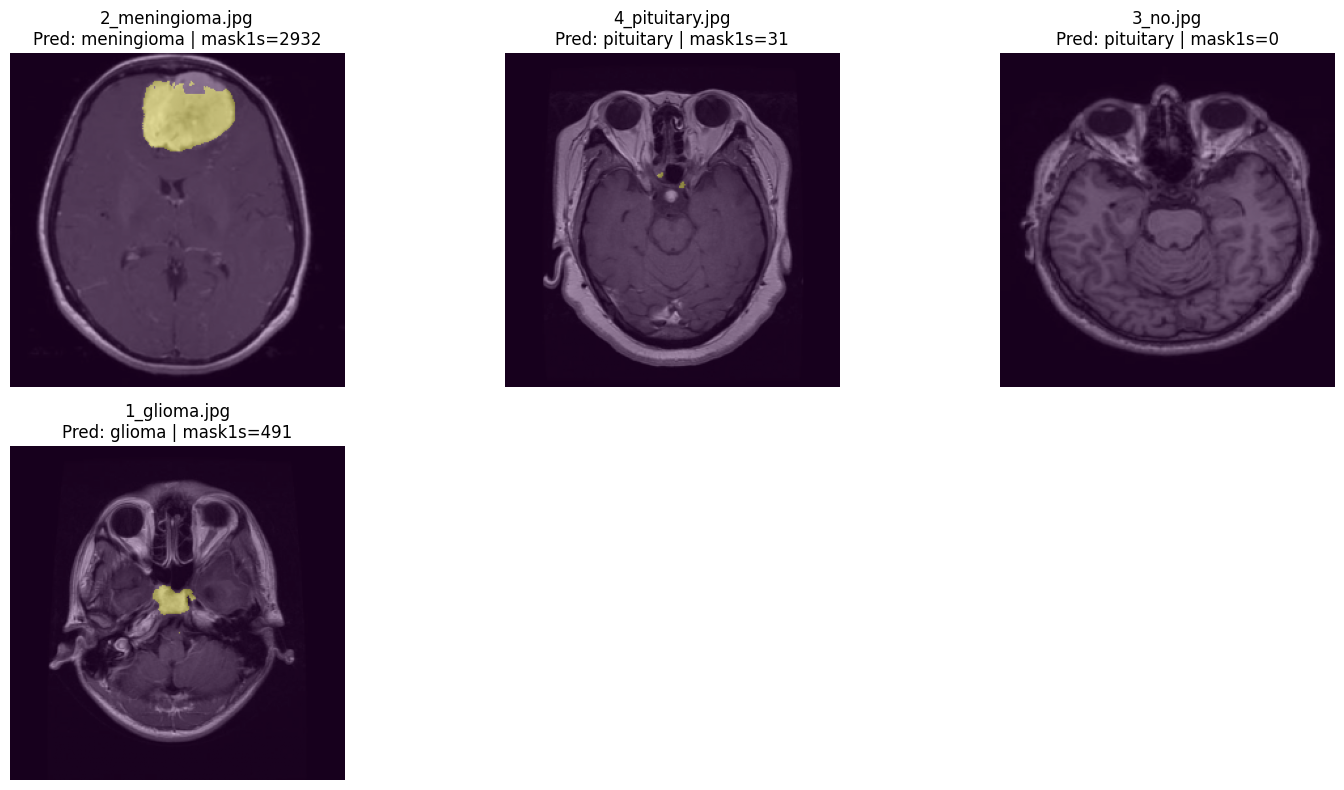


--- Top-3 Predictions ---
2_meningioma.jpg                meningioma=0.861, pituitary=0.130, glioma=0.009
4_pituitary.jpg                 pituitary=0.944, meningioma=0.055, glioma=0.001
3_no.jpg                        pituitary=0.856, meningioma=0.142, glioma=0.002
1_glioma.jpg                    glioma=0.884, meningioma=0.082, pituitary=0.035


In [ ]:
# ============================================================
# ✅ DEMO CELL (MULTIPLE IMAGES) — loads YOUR ckpt strictly
# Fixes key-mismatch by using Down.conv naming (down1.conv.*)
# ============================================================

import random
from pathlib import Path
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import cv2

# -------------------- EDIT THESE --------------------
CKPT_PATH = Path("unet_multitask_best.pt")  # your ckpt
INPUT_DIR = Path("/content/DEMO")         # folder of demo images
GLOB_PAT  = "*.jpg"
MAX_SHOW  = 12
# ---------------------------------------------------

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

ckpt = torch.load(CKPT_PATH, map_location=device)
state_dict = ckpt["state_dict"] if isinstance(ckpt, dict) and "state_dict" in ckpt else ckpt

IMG_SIZE = tuple(ckpt.get("img_size", (256, 256)))
THRESH = float(ckpt.get("threshold", 0.5))
class_names = ckpt.get("class_names", None)
USE_CLASSIFIER_HEAD = class_names is not None
base = int(ckpt.get("base", 32))

print("IMG_SIZE:", IMG_SIZE, "| THRESH:", THRESH, "| base:", base, "| classifier:", USE_CLASSIFIER_HEAD)

# ============================================================
# Model definitions MATCHING checkpoint key structure
# Down has: self.pool + self.conv  => down1.conv.net.*
# ============================================================

class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.pool = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        return self.conv(self.pool(x))
# build model that matches checkpoint
if USE_CLASSIFIER_HEAD:
    model = UNetWithClassifier(in_channels=1, num_classes=len(class_names), base=base).to(device).eval()
else:
    model = UNetOnly(in_channels=1, base=base).to(device).eval()

model.load_state_dict(state_dict, strict=True)
print("✅ Loaded checkpoint strictly:", CKPT_PATH)

# ============================================================
# image loader
# ============================================================
def read_gray01_resize(path: Path, img_size):
    img = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise RuntimeError(f"Could not read image: {path}")
    img = cv2.resize(img, (int(img_size[1]), int(img_size[0])), interpolation=cv2.INTER_AREA)
    return (img.astype(np.float32) / 255.0)

img_paths = sorted(INPUT_DIR.rglob(GLOB_PAT))
if len(img_paths) == 0:
    raise RuntimeError(f"No images found in {INPUT_DIR} with pattern {GLOB_PAT}")

random.shuffle(img_paths)
img_paths = img_paths[:MAX_SHOW]
print("Images to run:", len(img_paths))

# ============================================================
# inference
# ============================================================
results = []
with torch.no_grad():
    for p in img_paths:
        img01 = read_gray01_resize(p, IMG_SIZE)
        x = torch.from_numpy(img01[None, None, :, :]).float().to(device)

        out = model(x)
        if USE_CLASSIFIER_HEAD:
            seg_logits, cls_logits = out
            prob = torch.softmax(cls_logits, dim=1)[0].cpu().numpy()
            pred_id = int(np.argmax(prob))
            pred_name = class_names[pred_id]
        else:
            seg_logits = out
            pred_name = None

        seg_prob = torch.sigmoid(seg_logits)[0, 0].cpu().numpy()
        seg_mask = (seg_prob >= THRESH).astype(np.float32)

        results.append((p, img01, seg_mask, pred_name))

# ============================================================
# visualize
# ============================================================
cols = 3
rows = int(np.ceil(len(results)/cols))
plt.figure(figsize=(cols*5, rows*4))

for i, (p, img01, mask, pred_name) in enumerate(results, start=1):
    plt.subplot(rows, cols, i)
    plt.imshow(img01, cmap="gray")
    plt.imshow(mask, alpha=0.35)
    title = p.name
    if pred_name is not None:
        title += f"\nPred: {pred_name}"
    title += f" | mask1s={int(mask.sum())}"
    plt.title(title)
    plt.axis("off")

plt.tight_layout()
plt.show()

# print top-3 classes if classifier head exists
if USE_CLASSIFIER_HEAD:
    print("\n--- Top-3 Predictions ---")
    for p, _, _, _ in results:
        img01 = read_gray01_resize(p, IMG_SIZE)
        x = torch.from_numpy(img01[None, None, :, :]).float().to(device)
        with torch.no_grad():
            seg_logits, cls_logits = model(x)
            prob = torch.softmax(cls_logits, dim=1)[0].cpu().numpy()
        top3 = np.argsort(prob)[::-1][:3]
        print(f"{p.name:30s}  " + ", ".join([f"{class_names[j]}={prob[j]:.3f}" for j in top3]))